# Bayesian Rate-and-State GMSL Model

Extends the instantaneous Bayesian level-space model with a **state variable** $S(t)$ that captures the lagged response of deep ocean thermal expansion and ice-sheet dynamics to surface temperature forcing.

**Generative model:**
$$
\frac{dS}{dt} = \frac{T(t) - S(t)}{\tau}
$$
$$
\dot{H}(t) = a\,T(t)^2 + b\,T(t) + c + d\,(S(t) - T(t))
$$
$$
H(t) = H_0 + \int_0^t \dot{H}(\xi)\,d\xi
$$
$$
H_{\text{obs}}(t) \sim \mathcal{N}\bigl(H(t),\; \sigma_H(t)^2\bigr)
$$

**Physical interpretation:** During warming, $S < T$ (the state lags temperature), so $d \cdot (S - T) < 0$ — the realised SLR rate is *less* than the equilibrium rate because slow components (deep ocean, ice sheets) have not yet fully responded. After temperature stabilises, $S$ catches up and the disequilibrium vanishes.

**Limiting behaviour:** As $\tau \to 0$, $S \to T$ and $d \cdot (S - T) \to 0$, recovering the instantaneous model $\text{rate} = a\,T^2 + b\,T + c$.

**Key parameters:**
- $\tau$: Effective relaxation time (years) — captures the dominant ocean/ice sheet response timescale
- $d$: Disequilibrium strength (mm/yr/°C) — magnitude of committed but unrealised SLR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import arviz as az
from pathlib import Path

from bayesian_dols import (
    build_level_design_vectors,
    build_state_level_design_vectors,
    fit_bayesian_level,
    fit_bayesian_state_level,
    fit_satellite_era_quadratic,
    SatelliteEraQuadraticResult,
    solve_state_ode,
    calibrate_exponential_prior,
    calibrate_exponential_prior_a,
    prior_predictive_rate_check,
    BayesianLevelResult,
    BayesianStateLevelResult,
    check_convergence,
)
from slr_analysis import (
    calibrate_dols, 
    compute_kinematics,
    resample_to_monthly,
)
from slr_projections import (
    project_gmsl_ensemble,
    project_gmsl_state_ensemble,
    project_gmsl_tau_sensitivity,
)

# Constants
M_TO_MM = 1000.0
BASELINE_YEAR = 2005.0
N_SAMPLES = 5000
N_WALKERS = 64
N_BURNIN = 3000   # more burn-in for 7-dim nonlinear model

# Paths
BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data'
H5_PATH = DATA_DIR / 'processed' / 'slr_processed_data.h5'
FIG_DIR = BASE_DIR / 'figures'

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print(f'Constants: BASELINE_YEAR={BASELINE_YEAR}, '
      f'N_SAMPLES={N_SAMPLES}, N_WALKERS={N_WALKERS}, '
      f'N_BURNIN={N_BURNIN}')

Constants: BASELINE_YEAR=2005.0, N_SAMPLES=5000, N_WALKERS=64, N_BURNIN=3000


## 1. Data Loading

Load Frederikse GMSL + Berkeley Earth temperature data, plus IPCC temperature projections for forward runs.

In [2]:
# ============================================================
# Load data from HDF5
# ============================================================
with pd.HDFStore(str(H5_PATH), 'r') as store:
    config = store['/config']
    df_frederikse = store['/harmonized/df_frederikse_h']
    df_berkeley = store['/harmonized/df_berkeley_h']
    df_nasa_gmsl = store['/harmonized/df_nasa_gmsl_h']

    # Temperature projections for forward runs
    temp_projections_raw = {}
    ssp_keys = {
        'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
        'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
    }
    for name, key in ssp_keys.items():
        temp_projections_raw[name] = store[f'/projections/temp/{key}']

    # IPCC GMSL for comparison
    ipcc_gmsl = {}
    ssp_gmsl_keys = {
        'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
        'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
    }
    for name, key in ssp_gmsl_keys.items():
        ipcc_gmsl[name] = store[f'/projections/gmsl/{key}']

# Extract GMSL observations (Frederikse — for level-space model)
H_obs_full = df_frederikse['gmsl'].values            # meters
sigma_gmsl = df_frederikse['gmsl_sigma'].values      # meters
tws_sigma = df_frederikse['tws_sigma'].values        # meters
obs_years = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_frederikse.index
])

# NASA satellite altimetry (for rate prior — sub-monthly, 1993–2025)
nasa_time = df_nasa_gmsl['decimal_year'].values
nasa_gmsl = df_nasa_gmsl['gmsl'].values              # meters, GIA applied
ABLAIN_COV_PATH = str(DATA_DIR / 'raw' / 'gmslr'
                       / 'ablain2019_gmsl_error_covariance.nc')

# Monthly temperature (full record for ODE and projection spin-up)
T_monthly_all = df_berkeley['temperature'].values
time_monthly_all = np.array([
    t.year + (t.month - 0.5) / 12 for t in df_berkeley.index
])

# Restrict to observation period for calibration
mask_berk = ((time_monthly_all >= obs_years[0]) &
             (time_monthly_all <= obs_years[-1]))
T_monthly_fit = T_monthly_all[mask_berk]
time_monthly_fit = time_monthly_all[mask_berk]

# --- Rebaseline SSP temperatures from pre-industrial (~1850-1900)
# to the Berkeley Earth 1995-2005 baseline used for model calibration.
# Without this, rate = a*T² + b*T + c is evaluated at ~0.75°C too high,
# producing vastly inflated projections (quadratic amplification).
df_berk_annual = df_berkeley.resample('YE').mean().dropna(subset=['temperature'])
berk_annual_years = np.array([t.year + 0.5 for t in df_berk_annual.index])
berk_annual_T = df_berk_annual['temperature'].values

temp_projections = {}
for ssp_name, temp_df in temp_projections_raw.items():
    df_rb = temp_df.copy()
    T_proj = df_rb['temperature'].values.copy()
    if 'decimal_year' in df_rb.columns:
        t_proj = df_rb['decimal_year'].values
    else:
        t_proj = np.array([t.year + (t.month - 0.5) / 12 for t in df_rb.index])
    # Match IPCC and Berkeley Earth at the overlap year
    ipcc_first_year = t_proj[0]
    idx_overlap = np.argmin(np.abs(berk_annual_years - ipcc_first_year))
    berk_at_overlap = berk_annual_T[idx_overlap]
    ipcc_at_overlap = T_proj[0]
    temp_baseline_offset = ipcc_at_overlap - berk_at_overlap
    df_rb['temperature'] = T_proj - temp_baseline_offset
    if 'temperature_lower' in df_rb.columns:
        df_rb['temperature_lower'] -= temp_baseline_offset
        df_rb['temperature_upper'] -= temp_baseline_offset
    temp_projections[ssp_name] = df_rb

print(f'Frederikse GMSL: {len(H_obs_full)} annual obs, '
      f'{obs_years[0]:.1f}\u2013{obs_years[-1]:.1f}')
print(f'NASA altimetry:  {len(nasa_gmsl)} obs (~10-day), '
      f'{nasa_time[0]:.1f}\u2013{nasa_time[-1]:.1f}')
print(f'Berkeley Earth T: {len(T_monthly_fit)} monthly obs, '
      f'{time_monthly_fit[0]:.1f}\u2013{time_monthly_fit[-1]:.1f}')
print(f'Full T record: {len(T_monthly_all)} months, '
      f'{time_monthly_all[0]:.1f}\u2013{time_monthly_all[-1]:.1f}')
print(f'Temperature baseline offset (pre-industrial \u2192 Berkeley Earth): '
      f'{temp_baseline_offset:.3f} \u00b0C')
# Verify alignment
_t0 = t_proj[0]
_T0 = temp_projections['SSP2-4.5']['temperature'].iloc[0]
_Tb = np.interp(_t0, berk_annual_years, berk_annual_T)
print(f'Verification at {_t0:.0f}: SSP T = {_T0:.3f} \u00b0C, '
      f'Berkeley T = {_Tb:.3f} \u00b0C (diff = {_T0 - _Tb:.4f} \u00b0C)')

Frederikse GMSL: 119 annual obs, 1900.5–2018.5
NASA altimetry:  1191 obs (~10-day), 1993.0–2025.3
Berkeley Earth T: 1417 monthly obs, 1900.5–2018.5
Full T record: 2100 months, 1850.0–2025.0
Temperature baseline offset (pre-industrial → Berkeley Earth): 0.898 °C
Verification at 2015: SSP T = 0.213 °C, Berkeley T = 0.285 °C (diff = -0.0722 °C)


## 2. Observation Uncertainty Model

Same as the instantaneous model:
$$
\sigma(t)^2 = \sigma_{\text{gmsl}}(t)^2 + \sigma_{\text{TWS}}(t)^2 + \sigma_{\text{extra}}^2
$$
with dam-filling structural uncertainty Gaussian hump centred on 1970 (cf. Frederikse et al., 2020).

In [3]:
# ============================================================
# Observation uncertainty due to dam impoundment
# ============================================================
DAM_PEAK = 1970.0
DAM_WIDTH = 25.0
DAM_AMPLITUDE = 0.003  # 3 mm

dam_extra = DAM_AMPLITUDE * np.exp(
    -0.5 * ((obs_years - DAM_PEAK) / DAM_WIDTH)**2
)
sigma_tws_total = np.sqrt(tws_sigma**2 + dam_extra**2)
sigma_obs_fixed = np.sqrt(sigma_gmsl**2 + sigma_tws_total**2)

print(f'sigma_obs range: {sigma_obs_fixed.min()*M_TO_MM:.1f} to '
      f'{sigma_obs_fixed.max()*M_TO_MM:.1f} mm')

sigma_obs range: 4.4 to 20.6 mm


## 3. Design Vectors and State Variable

Pre-compute the $\tau$-independent design vectors ($I_2 = \int T^2$, $I_1 = \int T$, $I_0 = t - t_0$) and demonstrate the state variable $S(t)$ for several values of $\tau$.

Since $\tau$ varies at each MCMC step, $I_S = \int (S - T)\,d\tau$ must be recomputed inside the log-probability function. Only $I_2$, $I_1$, $I_0$ are constant.

Design vectors: 119 obs points from 1417 monthly grid


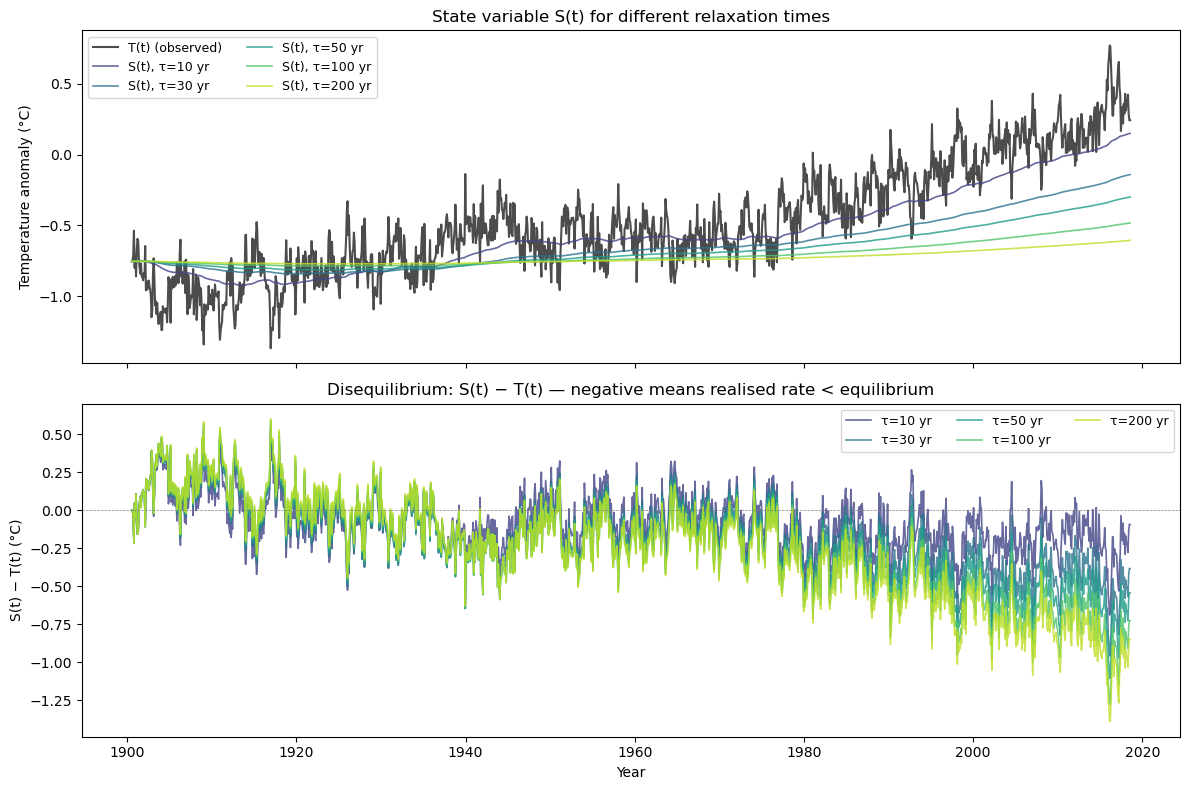


Disequilibrium at 2018 for each τ:
  τ=  10 yr: S-T = -0.094 °C
  τ=  30 yr: S-T = -0.384 °C
  τ=  50 yr: S-T = -0.543 °C
  τ= 100 yr: S-T = -0.727 °C
  τ= 200 yr: S-T = -0.850 °C


In [4]:
# ============================================================
# Build τ-independent design vectors
# ============================================================
dv = build_level_design_vectors(
    temperature_monthly=T_monthly_fit,
    time_monthly=time_monthly_fit,
    obs_times=obs_years,
)

I2_obs = dv['I2_obs']
I1_obs = dv['I1_obs']
I0_obs = dv['I0_obs']
obs_idx = dv['obs_idx']

print(f'Design vectors: {len(I2_obs)} obs points from '
      f'{len(T_monthly_fit)} monthly grid')

# ============================================================
# Demonstrate S(t) for several τ values
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: T(t) and S(t) for various τ
ax = axes[0]
ax.plot(time_monthly_fit, T_monthly_fit, 'k-', lw=1.5, alpha=0.7,
        label='T(t) (observed)')
tau_demo = [10, 30, 50, 100, 200]
colors_tau = plt.cm.viridis(np.linspace(0.2, 0.9, len(tau_demo)))
for tau_val, col in zip(tau_demo, colors_tau):
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    ax.plot(time_monthly_fit, S, '-', color=col, lw=1.2, alpha=0.8,
            label=f'S(t), \u03c4={tau_val} yr')
ax.set_ylabel('Temperature anomaly (\u00b0C)')
ax.set_title('State variable S(t) for different relaxation times')
ax.legend(fontsize=9, ncol=2)

# Panel 2: Disequilibrium S(t) - T(t)
ax = axes[1]
for tau_val, col in zip(tau_demo, colors_tau):
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    ax.plot(time_monthly_fit, S - T_monthly_fit, '-', color=col, lw=1.2,
            alpha=0.8, label=f'\u03c4={tau_val} yr')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('S(t) \u2212 T(t) (\u00b0C)')
ax.set_title('Disequilibrium: S(t) \u2212 T(t) — negative means realised rate < equilibrium')
ax.legend(fontsize=9, ncol=3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_state_variable_demo.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nDisequilibrium at 2018 for each \u03c4:')
for tau_val in tau_demo:
    S = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_val)
    diseq_end = S[-1] - T_monthly_fit[-1]
    print(f'  \u03c4={tau_val:>4d} yr: S-T = {diseq_end:+.3f} \u00b0C')

## 4. Model Specification

### Parameters (7 total)

| Parameter | Symbol | Prior | Physical motivation |
|-----------|--------|-------|--------------------|
| Temperature sensitivity of acceleration | $a$ (d$\alpha$/dT) | Exponential(mean = 2.2 mm/yr/$\degree$C$^2$) | PC prior: mode at $a=0$, shrinks toward order-1; calibrated via $P(a>5)=0.10$ |
| Linear warming sensitivity | $b$ ($\alpha_0$) | HalfNormal($\sigma$ = 10 mm/yr/$\degree$C) | Warming raises SLR; $b \geq 0$ |
| Background rate | $c$ (trend) | Normal(2.0, 5.0 mm/yr) | Rate at $T=0$; baseline-dependent |
| Disequilibrium strength | $d$ | Exponential(mean = 1.3 mm/yr/$\degree$C) | PC prior: mode at $d=0$, shrinks toward instantaneous; calibrated via $P(d>3)=0.10$ |
| Relaxation time | $\tau$ | LogNormal(log(20), 0.7) yr | Data-constrained: 5–81 yr (95% CI) |
| Model inadequacy | $\sigma_{\text{extra}}$ | HalfCauchy(0, 5 mm) | Unmodeled variability |
| Initial sea level | $H_0$ | Normal($H_{\text{obs}}(t_0)$, 50 mm) | Datum uncertainty |

Both $a$ and $d$ receive **Exponential (PC) priors**: $d=0$ removes the rate-and-state mechanism entirely (recovering the instantaneous model), while $a=0$ further simplifies to a linear temperature response. The priors have their modes at zero and provide genuine shrinkage toward the nested simpler model.

### $\tau$ prior justification

| Source | Component | $\tau$ estimate |
|--------|-----------|----------------|
| Caldeira & Myhrvold (2013) | Ocean mixed layer | ~32 yr |
| Vermeer & Rahmstorf (2009) | Semi-empirical fast component | ~50 yr |
| Mengel et al. (2016) | Fast thermal expansion | $\leq$100 yr |
| Yang et al. (2011) | Intermediate ocean (200–1000 m) | ~200 yr |
| Rignot et al. (2014); Joughin et al. (2014) | Ice sheet dynamic response | 100–500+ yr |
| Church et al. (2013); Clark et al. (2016) | Deep ocean + ice sheet equilibration | 500–2000+ yr |

**Why median = 20 yr?** The prior should concentrate mass where the 1900–2018 observational record has resolving power. The strongest transient feature in the instrumental record is the mid-20th century warming hiatus (~1940–1970), followed by a visible shallowing of GMSL trends with a lag of roughly 15–25 years. This is the *only* event in the record that can constrain $\tau$. A $\tau$ of 50 yr would produce a response lag extending into the 1990s, inconsistent with observations. With $\sigma = 0.7$, the LogNormal(log(20), 0.7) prior spans [5, 81 yr] (95% CI), covering the full range from upper-ocean mixed-layer response to intermediate timescales, while the data determine the posterior.

Longer timescales ($\tau > 100$ yr) — relevant for deep ocean and ice sheets — cannot be separately identified from a 119-year record. A future extension could use component-specific state variables ($S_{\text{thermo}}$, $S_{\text{glacier}}$, $S_{\text{GrIS}}$, $S_{\text{WAIS}}$) with individual $\tau$ values once longer records or process-model constraints become available.

=== Exponential (PC) Priors ===
  a ~ Exponential(mean = 2.171 mm/yr/°C²)
    P(a > 5 mm/yr/°C²) = 0.10
    P(a > 3 mm/yr/°C²) = 0.251
    P(a > 1 mm/yr/°C²) = 0.631
  d ~ Exponential(mean = 1.303 mm/yr/°C)
    P(d > 3 mm/yr/°C)  = 0.10
    P(d > 1 mm/yr/°C)  = 0.464

=== Prior Predictive Rate Check (mm/yr, excl. d) ===
  T (°C)     Median              5–95%
  ------------------------------------
  0.5           6.4 [   -2.9,    16.5]
  0.8           9.4 [   -1.2,    22.2]
  1.0          11.5 [   -0.1,    26.7]
  2.0          24.5 [    5.1,    55.9]
  4.0          60.8 [   15.4,   148.8]



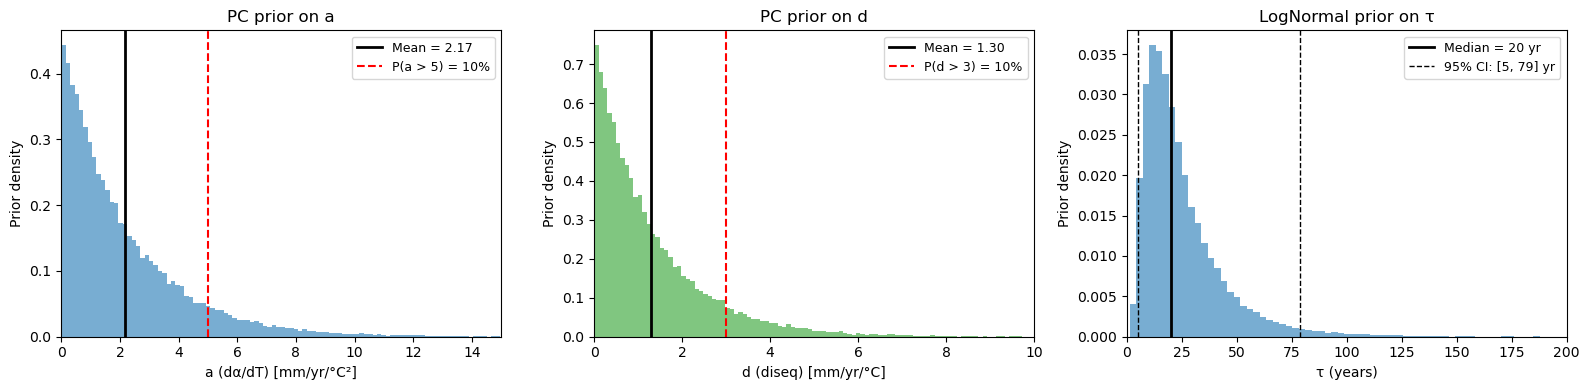

=== Full Prior Summary ===
  a (dα/dT): Exponential(mean = 2.17 mm/yr/°C²)
  b (α₀):    HalfNormal(σ = 10.0 mm/yr/°C)
  c (trend): Normal(2.0, 5.0 mm/yr)
  d (diseq): Exponential(mean = 1.30 mm/yr/°C)
  τ:         LogNormal(median=20 yr, 95% CI [5, 79] yr)
  σ_extra:   HalfCauchy(0, 5.0 mm)
  H₀:        Normal(H_obs[0], 50.0 mm)


In [5]:
# ============================================================
# Prior configuration (all in meters)
# ============================================================

# Quadratic coefficient a: Exponential (PC) prior
# Calibrated via tail probability: P(a > 5 mm/yr/°C²) = 10%
PRIOR_SCALE_A = calibrate_exponential_prior(
    prob_exceed=0.10,
    threshold=0.005,  # 5 mm/yr/°C² in m/yr/°C²
)

# Disequilibrium strength d: Exponential (PC) prior
# d=0 recovers the instantaneous model (no memory).
# Calibrated via P(d > 3 mm/yr/°C) = 10%
PRIOR_SCALE_D = calibrate_exponential_prior(
    prob_exceed=0.10,
    threshold=0.003,  # 3 mm/yr/°C in m/yr/°C
)

# Other priors unchanged
PRIOR_SCALE_B = 0.010           # HalfNormal sigma for b
PRIOR_C_MEAN = 0.002            # Normal mean for c
PRIOR_C_SIGMA = 0.005           # Normal sigma for c
PRIOR_LOG_TAU_MEAN = np.log(20) # LogNormal: median = 20 yr
PRIOR_LOG_TAU_SIGMA = 0.7       # LogNormal: log-space sigma
PRIOR_SIGMA_EXTRA_SCALE = 0.005 # HalfCauchy(5 mm)
PRIOR_H0_SIGMA = 0.050          # Normal sigma for H0

# --- Prior predictive check ---
pp_rates = prior_predictive_rate_check(
    PRIOR_SCALE_A, PRIOR_SCALE_B, PRIOR_C_MEAN, PRIOR_C_SIGMA,
    T_values=[0.5, 0.8, 1.0, 2.0, 4.0], seed=42,
)

print('=== Exponential (PC) Priors ===')
print(f'  a ~ Exponential(mean = {PRIOR_SCALE_A*M_TO_MM:.3f} mm/yr/°C²)')
print(f'    P(a > 5 mm/yr/°C²) = 0.10')
print(f'    P(a > 3 mm/yr/°C²) = {np.exp(-0.003/PRIOR_SCALE_A):.3f}')
print(f'    P(a > 1 mm/yr/°C²) = {np.exp(-0.001/PRIOR_SCALE_A):.3f}')
print(f'  d ~ Exponential(mean = {PRIOR_SCALE_D*M_TO_MM:.3f} mm/yr/°C)')
print(f'    P(d > 3 mm/yr/°C)  = 0.10')
print(f'    P(d > 1 mm/yr/°C)  = {np.exp(-0.001/PRIOR_SCALE_D):.3f}')
print()

print('=== Prior Predictive Rate Check (mm/yr, excl. d) ===')
print(f'  {"T (°C)":<8} {"Median":>8} {"5–95%":>18}')
print(f'  {"-"*36}')
for T, stats in pp_rates.items():
    print(f'  {T:<8.1f} {stats["median"]*M_TO_MM:8.1f} '
          f'[{stats["p5"]*M_TO_MM:7.1f}, {stats["p95"]*M_TO_MM:7.1f}]')
print()

# Visualise priors
tau_prior_samples = np.random.lognormal(PRIOR_LOG_TAU_MEAN,
                                         PRIOR_LOG_TAU_SIGMA, 50000)
tau_lo = np.exp(PRIOR_LOG_TAU_MEAN - 1.96 * PRIOR_LOG_TAU_SIGMA)
tau_hi = np.exp(PRIOR_LOG_TAU_MEAN + 1.96 * PRIOR_LOG_TAU_SIGMA)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: Exponential prior on a
ax = axes[0]
a_prior_samples = np.random.exponential(PRIOR_SCALE_A, 50000) * M_TO_MM
ax.hist(a_prior_samples[a_prior_samples < 15], bins=100, density=True,
        alpha=0.6, color='C0')
ax.axvline(PRIOR_SCALE_A * M_TO_MM, color='k', ls='-', lw=2,
           label=f'Mean = {PRIOR_SCALE_A*M_TO_MM:.2f}')
ax.axvline(5.0, color='red', ls='--', lw=1.5,
           label='P(a > 5) = 10%')
ax.set_xlabel('a (dα/dT) [mm/yr/°C²]')
ax.set_ylabel('Prior density')
ax.set_title('PC prior on a')
ax.legend(fontsize=9)
ax.set_xlim(0, 15)

# Middle: Exponential prior on d
ax = axes[1]
d_prior_samples = np.random.exponential(PRIOR_SCALE_D, 50000) * M_TO_MM
ax.hist(d_prior_samples[d_prior_samples < 10], bins=100, density=True,
        alpha=0.6, color='C2')
ax.axvline(PRIOR_SCALE_D * M_TO_MM, color='k', ls='-', lw=2,
           label=f'Mean = {PRIOR_SCALE_D*M_TO_MM:.2f}')
ax.axvline(3.0, color='red', ls='--', lw=1.5,
           label='P(d > 3) = 10%')
ax.set_xlabel('d (diseq) [mm/yr/°C]')
ax.set_ylabel('Prior density')
ax.set_title('PC prior on d')
ax.legend(fontsize=9)
ax.set_xlim(0, 10)

# Right: τ prior (unchanged)
ax = axes[2]
ax.hist(tau_prior_samples[tau_prior_samples < 300], bins=100,
        density=True, alpha=0.6, color='C0')
ax.axvline(20, color='k', ls='-', lw=2, label=f'Median = 20 yr')
ax.axvline(tau_lo, color='k', ls='--', lw=1,
           label=f'95% CI: [{tau_lo:.0f}, {tau_hi:.0f}] yr')
ax.axvline(tau_hi, color='k', ls='--', lw=1)
ax.set_xlabel('τ (years)')
ax.set_ylabel('Prior density')
ax.set_title('LogNormal prior on τ')
ax.legend(fontsize=9)
ax.set_xlim(0, 200)

plt.savefig(FIG_DIR / 'ratestate_priors.png',bbox_inches='tight')

plt.tight_layout()
plt.show()

print('=== Full Prior Summary ===')
print(f'  a (dα/dT): Exponential(mean = {PRIOR_SCALE_A*M_TO_MM:.2f} mm/yr/°C²)')
print(f'  b (α₀):    HalfNormal(σ = {PRIOR_SCALE_B*M_TO_MM:.1f} mm/yr/°C)')
print(f'  c (trend): Normal({PRIOR_C_MEAN*M_TO_MM:.1f}, {PRIOR_C_SIGMA*M_TO_MM:.1f} mm/yr)')
print(f'  d (diseq): Exponential(mean = {PRIOR_SCALE_D*M_TO_MM:.2f} mm/yr/°C)')
print(f'  τ:         LogNormal(median=20 yr, 95% CI [{tau_lo:.0f}, {tau_hi:.0f}] yr)')
print(f'  σ_extra:   HalfCauchy(0, {PRIOR_SIGMA_EXTRA_SCALE*M_TO_MM:.1f} mm)')
print(f'  H₀:        Normal(H_obs[0], {PRIOR_H0_SIGMA*M_TO_MM:.1f} mm)')

## 4b. Satellite-Era Rate Prior

Quadratic fit to NASA satellite altimetry (1993–2023) with a rigorous
three-component error budget following Hamlington et al. (2024):

1. **Measurement errors** — Ablain et al. (2019) error covariance matrix
2. **Serial correlation** — Maul & Martin (1993) lag-1 inflation
3. **GIA uncertainty** — Caron et al. (2018), 0.15 mm/yr (1σ), rate only

This provides a bivariate Gaussian prior on (rate, accel) at the end of the
Frederikse record (~2018.5) that regularises the level-space models.

=== NASA Satellite Altimetry Quadratic Fit (1993–2023) ===
  method: full_error_budget
  n_obs: 1123 (~10-day cadence)
  R² = 0.9696
  Acceleration: 68.66 ± 63.64 μm/yr² (= 0.0687 ± 0.0636 mm/yr²)

  --- Midpoint comparison (2008.2) ---
                                     Ours (1σ)    Hamlington 90% CI
  ---------------------------------------------------------------
  Rate (mm/yr)                 3.235 ± 0.245     3.3 ± 0.3
  Accel (mm/yr²)              0.0687 ± 0.0424   0.08 ± 0.06

  --- Rate prior @ 2018.5 (σ inflated ×1.5) ---
  Rate:  3.941 ± 0.747 mm/yr (1σ)
  Accel: 68.66 ± 63.64 μm/yr² (1σ)
  Rate–accel correlation: 0.871

  Frederikse kinematics (20-yr) at 2018.5: 6.504 ± 0.824 mm/yr


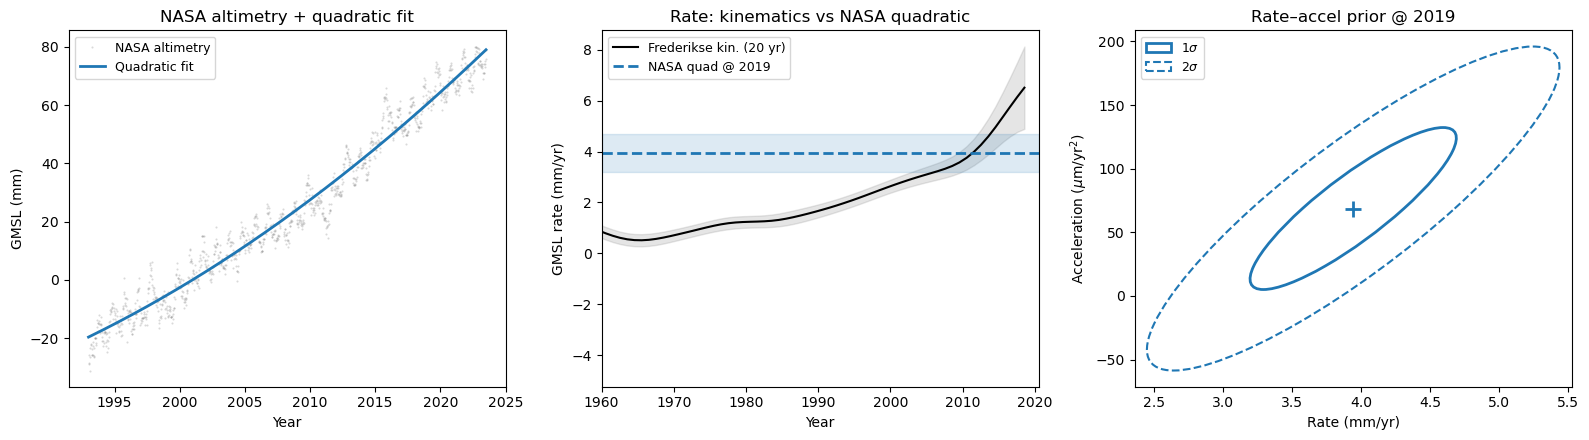

In [6]:
# ============================================================
# Satellite-era rate prior from NASA altimetry
# ============================================================
# Full error budget: measurement (Ablain 2019) + serial correlation
# (Maul & Martin 1993) + GIA (Caron 2018).
# Evaluated at 2018.5 (end of Frederikse record) with σ inflation
# of 1.5 to account for partial information overlap with the
# level-space likelihood.

sat_quad = fit_satellite_era_quadratic(
    time=nasa_time,
    gmsl=nasa_gmsl,
    sigma=None,                    # OLS — NASA σ is spatial variability
    t_start=1993.0,
    t_end=2023.5,                  # match Hamlington et al. (2024)
    eval_time=obs_years[-1],       # end of Frederikse record
    sigma_inflate=1.5,
    meas_cov_path=ABLAIN_COV_PATH,
    sigma_gia=0.15e-3,             # 0.15 mm/yr (1σ), Caron et al. 2018
)

# Also compute at midpoint for comparison with Hamlington
sat_quad_mid = fit_satellite_era_quadratic(
    time=nasa_time,
    gmsl=nasa_gmsl,
    sigma=None,
    t_start=1993.0,
    t_end=2023.5,
    eval_time=0.5 * (1993.0 + 2023.5),  # midpoint ~2008.3
    sigma_inflate=1.0,                    # no inflation for comparison
    meas_cov_path=ABLAIN_COV_PATH,
    sigma_gia=0.15e-3,
)

print('=== NASA Satellite Altimetry Quadratic Fit (1993–2023) ===')
print(f'  method: {sat_quad.fit_method}')
print(f'  n_obs: {sat_quad.n_obs} (~10-day cadence)')
print(f'  R² = {sat_quad.r2:.4f}')
print(f'  Acceleration: {sat_quad.accel*1e6:.2f} '
      f'± {sat_quad.accel_se*1e6:.2f} μm/yr² '
      f'(= {sat_quad.accel*M_TO_MM:.4f} '
      f'± {sat_quad.accel_se*M_TO_MM:.4f} mm/yr²)')
print()

# Midpoint comparison with Hamlington et al. (2024)
print(f'  --- Midpoint comparison ({sat_quad_mid.eval_time:.1f}) ---')
print(f'  {"":25} {"Ours (1σ)":>18} {"Hamlington 90% CI":>20}')
print(f'  {"-"*63}')
print(f'  {"Rate (mm/yr)":<25} '
      f'{sat_quad_mid.rate*M_TO_MM:8.3f} ± {sat_quad_mid.rate_se*M_TO_MM:.3f}'
      f'{"3.3 ± 0.3":>14}')
print(f'  {"Accel (mm/yr²)":<25} '
      f'{sat_quad_mid.accel*M_TO_MM:8.4f} ± {sat_quad_mid.accel_se*M_TO_MM:.4f}'
      f'{"0.08 ± 0.06":>14}')
print()

# Rate prior values (with σ inflation)
corr = (sat_quad.rate_accel_cov[0, 1]
        / np.sqrt(sat_quad.rate_accel_cov[0, 0]
                  * sat_quad.rate_accel_cov[1, 1]))
print(f'  --- Rate prior @ {sat_quad.eval_time:.1f} (σ inflated ×1.5) ---')
print(f'  Rate:  {sat_quad.rate*M_TO_MM:.3f} '
      f'± {sat_quad.rate_se*M_TO_MM:.3f} mm/yr (1σ)')
print(f'  Accel: {sat_quad.accel*1e6:.2f} '
      f'± {sat_quad.accel_se*1e6:.2f} μm/yr² (1σ)')
print(f'  Rate–accel correlation: {corr:.3f}')

# --- Diagnostic: compare with kinematics ---
kin = compute_kinematics(
    time=obs_years,
    value=H_obs_full,
    sigma=sigma_obs_fixed,
    span_years=20,
)
idx_end = np.argmin(np.abs(kin.time - sat_quad.eval_time))
print(f'\n  Frederikse kinematics (20-yr) at {kin.time[idx_end]:.1f}: '
      f'{kin.rate[idx_end]*M_TO_MM:.3f} '
      f'± {kin.rate_se[idx_end]*M_TO_MM:.3f} mm/yr')

# --- Figure: 3-panel diagnostic ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left: NASA GMSL with quadratic fit overlay
ax = axes[0]
mask_plot = nasa_time <= 2023.5
ax.plot(nasa_time[mask_plot], nasa_gmsl[mask_plot] * M_TO_MM,
        '.', ms=1, alpha=0.3, color='grey', label='NASA altimetry')
dt_plot = np.linspace(0, 2023.5 - 1993.0, 300)
H_fit = (sat_quad.coefficients[0]
         + sat_quad.coefficients[1] * dt_plot
         + sat_quad.coefficients[2] * dt_plot**2) * M_TO_MM
ax.plot(dt_plot + 1993.0, H_fit, 'C0-', lw=2, label='Quadratic fit')
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm)')
ax.set_title('NASA altimetry + quadratic fit')
ax.legend(fontsize=9)

# Middle: rate comparison
ax = axes[1]
ax.plot(kin.time, kin.rate * M_TO_MM, 'k-', lw=1.5,
        label='Frederikse kin. (20 yr)')
ax.fill_between(kin.time,
                (kin.rate - 1.96 * kin.rate_se) * M_TO_MM,
                (kin.rate + 1.96 * kin.rate_se) * M_TO_MM,
                alpha=0.2, color='grey')
ax.axhline(sat_quad.rate * M_TO_MM, color='C0', ls='--', lw=2,
           label=f'NASA quad @ {sat_quad.eval_time:.0f}')
ax.axhspan((sat_quad.rate - sat_quad.rate_se) * M_TO_MM,
           (sat_quad.rate + sat_quad.rate_se) * M_TO_MM,
           alpha=0.15, color='C0')
ax.set_xlabel('Year')
ax.set_ylabel('GMSL rate (mm/yr)')
ax.set_title('Rate: kinematics vs NASA quadratic')
ax.set_xlim(1960, sat_quad.eval_time + 2)
ax.legend(fontsize=9)

# Right: rate-accel joint prior ellipse (unfilled, distinct line styles)
ax = axes[2]
from matplotlib.patches import Ellipse
mean = np.array([sat_quad.rate * M_TO_MM, sat_quad.accel * 1e6])
cov_plot = np.array([
    [sat_quad.rate_accel_cov[0, 0] * M_TO_MM**2,
     sat_quad.rate_accel_cov[0, 1] * M_TO_MM * 1e6],
    [sat_quad.rate_accel_cov[1, 0] * M_TO_MM * 1e6,
     sat_quad.rate_accel_cov[1, 1] * 1e12],
])
eigvals, eigvecs = np.linalg.eigh(cov_plot)
angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
for nsig, ls, lw in [(1, '-', 2.0), (2, '--', 1.5)]:
    w = 2 * nsig * np.sqrt(eigvals[1])
    h = 2 * nsig * np.sqrt(eigvals[0])
    ell = Ellipse(mean, w, h, angle=angle, fill=False,
                  edgecolor='C0', lw=lw, ls=ls,
                  label=f'{nsig}$\\sigma$')
    ax.add_patch(ell)
ax.plot(*mean, 'C0+', ms=12, mew=2)
ax.set_xlabel('Rate (mm/yr)')
ax.set_ylabel('Acceleration ($\\mu$m/yr$^2$)')
ax.set_title(f'Rate\u2013accel prior @ {sat_quad.eval_time:.0f}')
ax.set_aspect('auto')
ax.autoscale()
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_satellite_era_prior.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 5. MCMC Sampling

### Two-step initialisation strategy

The 5-regressor OLS problem ($I_2, I_1, I_0, I_S, \mathbf{1}$) is severely ill-conditioned because $I_S$ is strongly collinear with $I_1$ and $I_0$. OLS typically yields negative $d$ and $b$, violating the physical priors and placing walkers far from the posterior.

**Solution**: First fit the **instantaneous model** (the $\tau \to 0$ limit with $d=0$), which converges easily. Then initialise the rate-and-state sampler from its posterior: $(a, b, c)$ from the instantaneous fit, $d \approx 0$, and $\tau$ at the prior median. This gives walkers a feasible, high-probability starting point and lets the MCMC explore whether the data support $d > 0$ (and what $\tau$ is).

Settings: 64 walkers, 3000 burn-in, 5000 production steps. The nonlinearity from $\tau$ (ODE re-solved at each step) makes this ~3× more expensive per evaluation than the instantaneous model.

In [7]:
# ============================================================
# Step 1: Fit the INSTANTANEOUS model (τ→0 limit, d=0)
# ============================================================
print('='*70)
print('Step 1: Instantaneous model (τ→0 limit)')
print('='*70)
inst_result = fit_bayesian_level(
    H_obs=H_obs_full,
    sigma_obs=sigma_obs_fixed,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    prior_scale_a=PRIOR_SCALE_A,
    prior_scale_b=PRIOR_SCALE_B,
    prior_c_mean=PRIOR_C_MEAN,
    prior_c_sigma=PRIOR_C_SIGMA,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
    prior_H0_sigma=PRIOR_H0_SIGMA,
    n_samples=N_SAMPLES,
    n_walkers=N_WALKERS,
    n_burnin=1000,  # instantaneous model converges fast
    progress=True,
    seed=42,
    rate_prior=sat_quad,
    temperature_monthly=T_monthly_all,      # full record, not truncated
    time_monthly=time_monthly_all,          # avoids boundary effects on dT/dt
    obs_times=obs_years,
)

print(f'\nInstantaneous R² = {inst_result.r2:.4f}')
print(f'Coefficients (mm/yr): a={inst_result.physical_coefficients[0]*M_TO_MM:.3f}, '
      f'b={inst_result.physical_coefficients[1]*M_TO_MM:.3f}, '
      f'c={inst_result.physical_coefficients[2]*M_TO_MM:.3f}')

# ============================================================
# Step 2: Fit the RATE-AND-STATE model
# Initialise from order=1 (linear): a≈0, consistent with PC prior.
# Lets the MCMC decide whether a, d, or both explain nonlinearity.
# ============================================================
# Extend T_monthly_fit to ±5 yr beyond the Frederikse record so that
# the dT/dt estimate for the rate prior has a symmetric window.
# The ODE solve needs T(t) over the calibration period; extending
# a few years beyond is harmless (the ODE just runs a bit longer).
mask_berk_ext = ((time_monthly_all >= obs_years[0]) &
                 (time_monthly_all <= obs_years[-1] + 6.0))
T_monthly_ext = T_monthly_all[mask_berk_ext]
time_monthly_ext = time_monthly_all[mask_berk_ext]
# obs_idx must map into the extended grid
obs_idx_ext = np.array([
    np.argmin(np.abs(time_monthly_ext - yr)) for yr in obs_years
])

print('\n' + '='*70)
print('Step 2: Rate-and-state model (initialised from linear subspace)')
print('='*70)
state_result = fit_bayesian_state_level(
    H_obs=H_obs_full,
    sigma_obs=sigma_obs_fixed,
    I2_obs=I2_obs,
    I1_obs=I1_obs,
    I0_obs=I0_obs,
    T_monthly=T_monthly_ext,
    time_monthly=time_monthly_ext,
    obs_idx=obs_idx_ext,
    prior_scale_a=PRIOR_SCALE_A,
    prior_scale_b=PRIOR_SCALE_B,
    prior_c_mean=PRIOR_C_MEAN,
    prior_c_sigma=PRIOR_C_SIGMA,
    prior_scale_d=PRIOR_SCALE_D,
    prior_log_tau_mean=PRIOR_LOG_TAU_MEAN,
    prior_log_tau_sigma=PRIOR_LOG_TAU_SIGMA,
    prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
    prior_H0_sigma=PRIOR_H0_SIGMA,
    n_samples=N_SAMPLES,
    n_walkers=N_WALKERS,
    n_burnin=N_BURNIN,
    progress=True,
    seed=42,
    init_from_level=inst_result,
    init_order=1,
    rate_prior=sat_quad,
)

# Summary table
print('\n' + '=' * 70)
print('Rate-and-State Posterior Summary (mm/yr)')
print('=' * 70)
names_phys = ['dα/dT', 'α₀', 'trend', 'd (diseq)']
print(f'{"Parameter":<14} {"Mean":>10} {"94% HDI":>24}')
print('-' * 50)
for k, name in enumerate(names_phys):
    v = state_result.physical_coefficients[k] * M_TO_MM
    hdi = state_result.physical_hdi_94[k] * M_TO_MM
    print(f'{name:<14} {v:10.3f}      [{hdi[0]:.3f}, {hdi[1]:.3f}]')

tau_post = state_result.tau_posterior
print(f'\nτ: median={np.median(tau_post):.1f} yr '
      f'[{np.percentile(tau_post, 3):.1f}, '
      f'{np.percentile(tau_post, 97):.1f}] (94% HDI)')
print(f'σ_extra: median={np.median(state_result.sigma_extra_posterior)*M_TO_MM:.2f} mm '
      f'[{np.percentile(state_result.sigma_extra_posterior, 3)*M_TO_MM:.2f}, '
      f'{np.percentile(state_result.sigma_extra_posterior, 97)*M_TO_MM:.2f}]')
print(f'R² = {state_result.r2:.4f}')

Step 1: Instantaneous model (τ→0 limit)
Bayesian level-space fit: n=119 observations, ndim=5
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr), σ_extra~HC(5.0 mm)
  Rate prior: rate=3.94 ± 0.75 mm/yr, accel=68.66 ± 63.64 μm/yr², T_end=0.244 °C, dT/dt=17.18 m°C/yr
  OLS init: a=3.024, b=3.754, c=2.428 mm/yr, σ_extra=9.33 mm


100%|████████████████████████████████████████████████████████████████| 6000/6000 [00:21<00:00, 274.25it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.008  ESS_bulk=318  ESS_tail=851
    alpha0: R-hat=1.007  ESS_bulk=316  ESS_tail=861
    trend: R-hat=1.013  ESS_bulk=363  ESS_tail=1329
    log_sigma_extra: R-hat=1.021  ESS_bulk=286  ESS_tail=420
    H0: R-hat=1.010  ESS_bulk=352  ESS_tail=963
  All diagnostics OK (R-hat < 1.05, ESS > 100)
  Posterior mean: a=4.573, b=5.016, c=2.509 mm/yr
  σ_extra: median=1.24 mm [0.07, 3.51]
  R² = 0.9696,  acceptance = 0.54

Instantaneous R² = 0.9696
Coefficients (mm/yr): a=4.573, b=5.016, c=2.509

Step 2: Rate-and-state model (initialised from linear subspace)
Bayesian rate-and-state fit: n=119 obs, ndim=7
  Priors: a~Exp(mean=2.17 mm/yr/°C²), b~HN(10.0 mm/yr/°C), c~N(2.0, 5.0 mm/yr)
  d~Exp(mean=1.30 mm/yr/°C), τ~LogN(median=20 yr, 95% CI [5, 79] yr)
  σ_extra~HC(5.0 mm)
  Rate prior: rate=3.94 ± 0.75 mm/yr, accel=68.66 ± 63.64 μm/yr², T_end=0.244 °C, dT/dt=17.18 m°C/yr
  Init (from instantaneous model (order=1, a≈0)): a=0.010, b=5.016, c=2.509, d

100%|█████████████████████████████████████████████████████████████████| 8000/8000 [37:57<00:00,  3.51it/s]


  Convergence diagnostics:
    dalpha_dT: R-hat=1.026  ESS_bulk=150  ESS_tail=584
    alpha0: R-hat=1.033  ESS_bulk=149  ESS_tail=448
    trend: R-hat=1.097  ESS_bulk=36  ESS_tail=90
    d_diseq: R-hat=1.060  ESS_bulk=69  ESS_tail=154
    log_tau: R-hat=1.029  ESS_bulk=118  ESS_tail=469
    log_sigma_extra: R-hat=1.008  ESS_bulk=188  ESS_tail=321
    H0: R-hat=1.010  ESS_bulk=198  ESS_tail=586
  WARNINGS:
  trend: R-hat = 1.097 > 1.05 — chains have NOT converged
  trend: bulk ESS = 36 < 100 — increase samples or walkers
  trend: tail ESS = 90 < 100 — tail estimates unreliable
  d_diseq: R-hat = 1.060 > 1.05 — chains have NOT converged
  d_diseq: bulk ESS = 69 < 100 — increase samples or walkers

  Posterior mean: a=4.565, b=5.192, c=2.668, d=0.707 mm/yr
  τ: median=15.2 yr [3.9, 74.6]
  σ_extra: median=1.30 mm [0.07, 3.64]
  R² = 0.9677,  acceptance = 0.39

Rate-and-State Posterior Summary (mm/yr)
Parameter            Mean                  94% HDI
--------------------------------------

## 6. Posterior Diagnostics

Trace plots for all 7 parameters, with particular attention to $\log\tau$ mixing (the only nonlinear parameter).

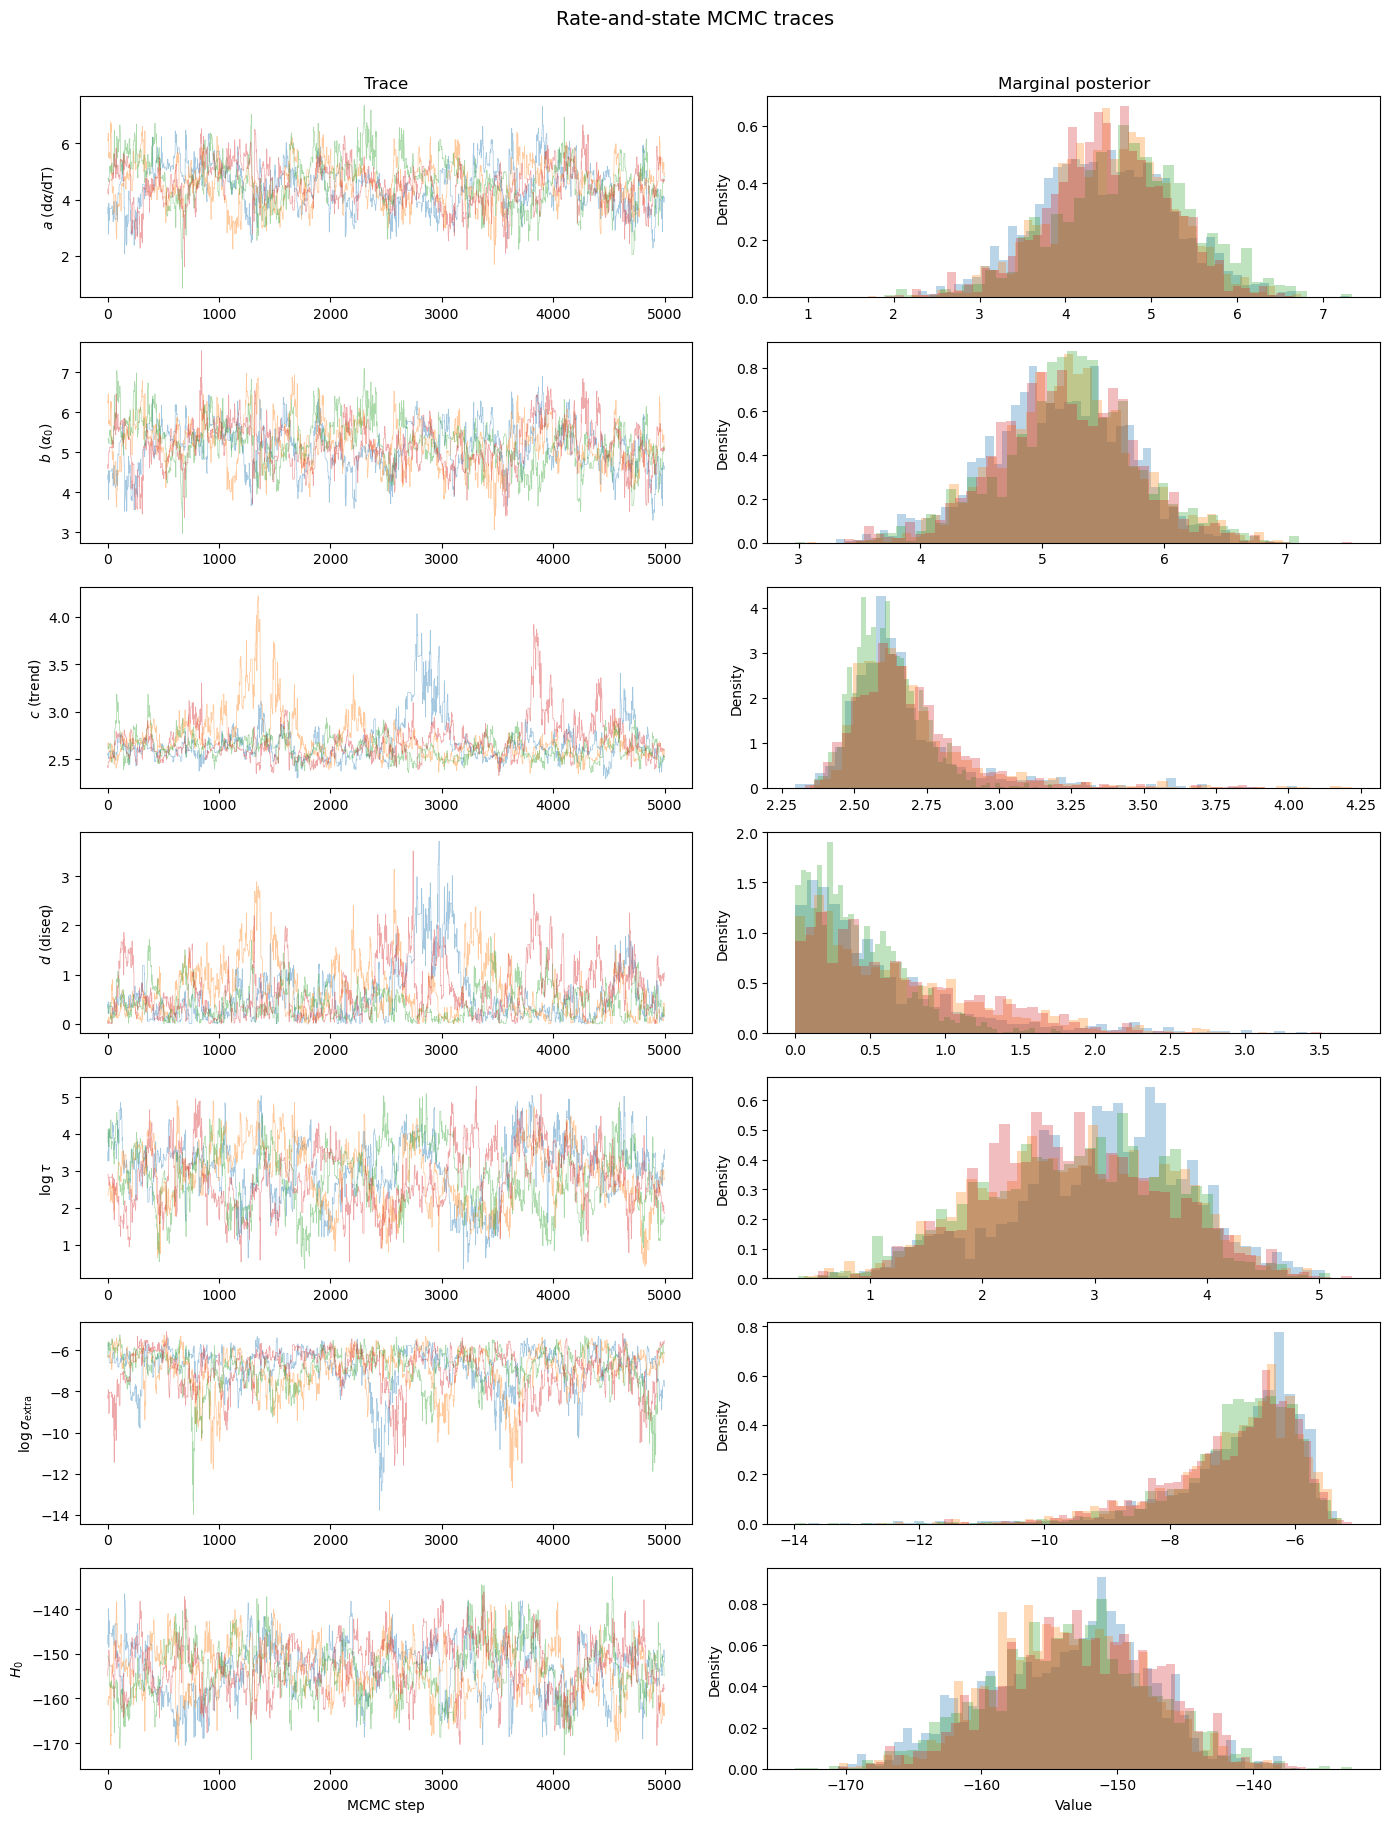

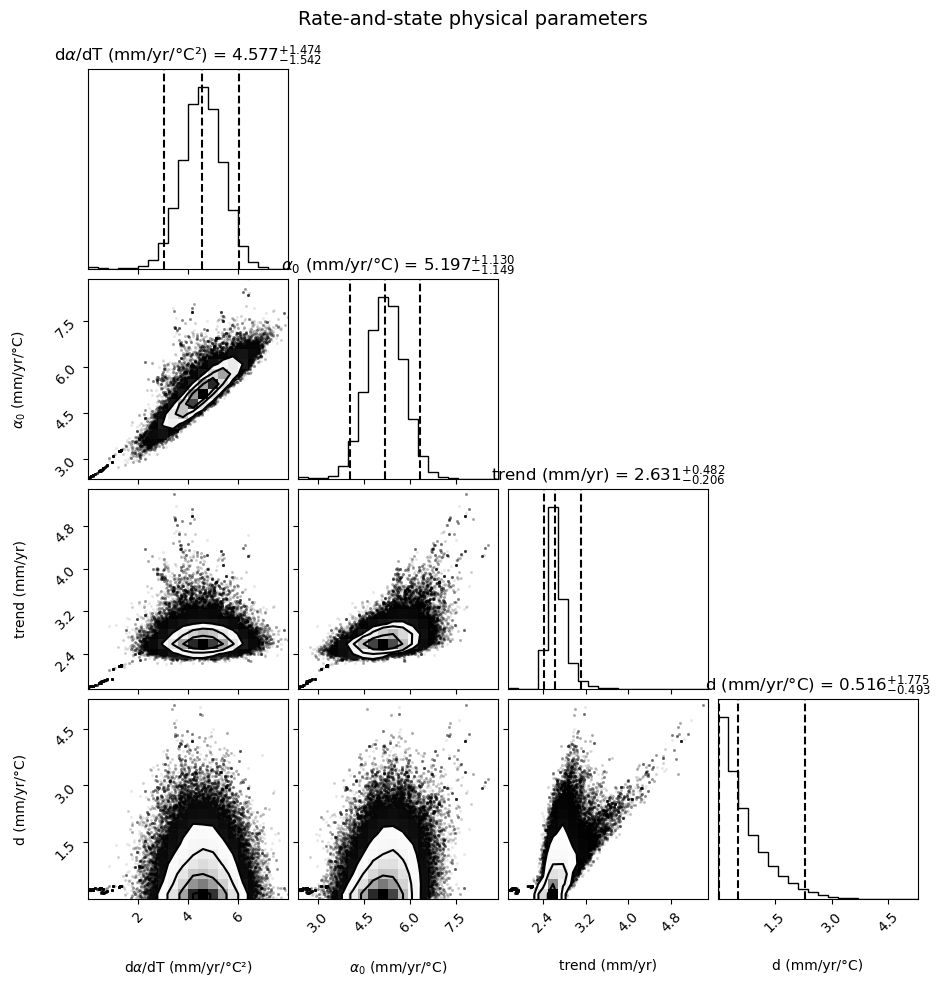

Acceptance fraction: 0.386
R-hat max: N/A
ESS min:   N/A
Converged: False


In [8]:
# ============================================================
# Trace plots (7 parameters)
# ============================================================
fig, axes = plt.subplots(7, 2, figsize=(14, 18))
param_labels = [
    r'$a$ (d$\alpha$/dT)', r'$b$ ($\alpha_0$)', r'$c$ (trend)',
    r'$d$ (diseq)', r'$\log\tau$', r'$\log\sigma_{\rm extra}$', r'$H_0$'
]
param_names_trace = [
    'dalpha_dT', 'alpha0', 'trend', 'd_diseq',
    'log_tau', 'log_sigma_extra', 'H0'
]
chain_full = state_result.trace.posterior

for i, (name, label) in enumerate(zip(param_names_trace, param_labels)):
    data = chain_full[name].values
    # Scale physical params to mm
    scale = M_TO_MM if i in [0, 1, 2, 3] else (M_TO_MM if i == 6 else 1.0)

    ax = axes[i, 0]
    for ch in range(data.shape[0]):
        ax.plot(data[ch] * scale, alpha=0.4, lw=0.5)
    ax.set_ylabel(label)
    if i == 0:
        ax.set_title('Trace')

    ax = axes[i, 1]
    for ch in range(data.shape[0]):
        ax.hist(data[ch].ravel() * scale, bins=50, alpha=0.3, density=True)
    ax.set_ylabel('Density')
    if i == 0:
        ax.set_title('Marginal posterior')

axes[-1, 0].set_xlabel('MCMC step')
axes[-1, 1].set_xlabel('Value')
plt.suptitle('Rate-and-state MCMC traces', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_traces.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Corner plot (a, b, c, d)
# ============================================================
try:
    import corner
    labels_corner = [
        r'd$\alpha$/dT (mm/yr/°C²)', r'$\alpha_0$ (mm/yr/°C)',
        r'trend (mm/yr)', r'd (mm/yr/°C)'
    ]
    fig_corner = corner.corner(
        state_result.posterior_samples * M_TO_MM,
        labels=labels_corner,
        quantiles=[0.03, 0.50, 0.97],
        show_titles=True,
        title_fmt='.3f',
    )
    fig_corner.suptitle('Rate-and-state physical parameters',
                        fontsize=14, y=1.02)
    plt.savefig(FIG_DIR / 'ratestate_corner.png', dpi=150,
                bbox_inches='tight')
    plt.show()
except ImportError:
    print('corner not installed \u2014 skipping')

# Convergence diagnostics
diag = state_result.sampler_diagnostics
print(f"Acceptance fraction: {diag['acceptance_fraction']:.3f}")
conv = diag.get('convergence', {})
if conv:
    print(f"R-hat max: {conv.get('rhat_max', 'N/A')}")
    print(f"ESS min:   {conv.get('ess_min', 'N/A')}")
    print(f"Converged: {conv.get('converged', 'N/A')}")

### Rate Prior Diagnostic: Posterior-Implied Rate vs Observations

Verify that the satellite-era rate prior is working as intended by comparing
the posterior-implied rate at end of record against the quadratic fit and
kinematic estimates.

T_end = 0.244 °C at 2018.5
dT/dt = 17.18 m°C/yr (±5 yr window, full record)


Rate-state posterior:   0%|          | 0/320000 [00:00<?, ?it/s]


End-of-Record Rate Comparison at 2019 (mm/yr)
Source                               Rate       ± 1σ   Accel (μm/yr²)
----------------------------------------------------------------------
Satellite-era quadratic             3.941      0.747            68.66
Kinematics (20 yr)                  6.504      0.824           344.31
Instantaneous model                 4.006      0.219           124.71
Rate-and-state model                4.083      0.256           121.41


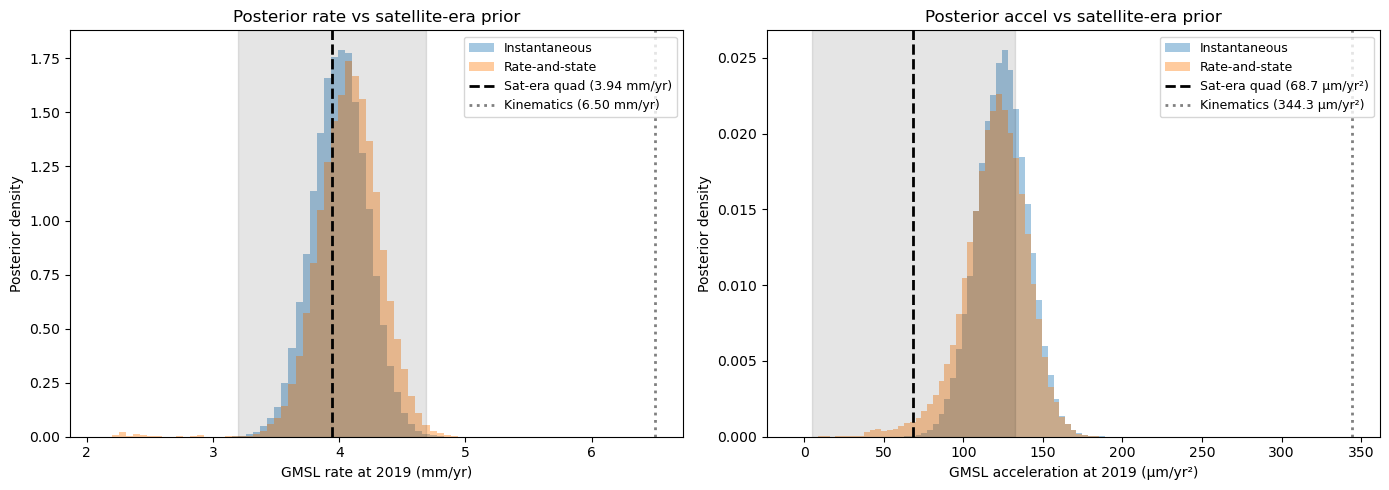

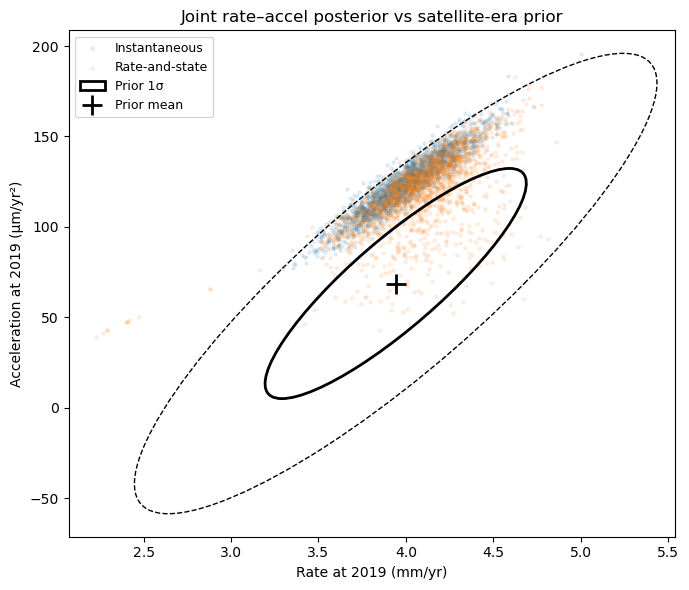

In [9]:
# ============================================================
# Rate Prior Diagnostic: posterior-implied rate vs observations
# ============================================================

# --- Compute T_end and dT/dt at the rate prior evaluation epoch ---
# Use the FULL Berkeley Earth record (time_monthly_all) with a ±5 yr
# window for dT/dt, matching the window used inside fit_bayesian_level().
# Using time_monthly_fit (truncated to the Frederikse period) with a
# narrow window gives a one-sided sample dominated by the post-2016
# El Niño cooling, producing a spurious negative dT/dt.
idx_eval = np.argmin(np.abs(time_monthly_fit - sat_quad.eval_time))
T_end = T_monthly_fit[idx_eval]
dt_w = 5.0
mask_w = ((time_monthly_all >= sat_quad.eval_time - dt_w) &
          (time_monthly_all <= sat_quad.eval_time + dt_w))
dTdt_end = np.polyfit(time_monthly_all[mask_w], T_monthly_all[mask_w], 1)[0]

print(f'T_end = {T_end:.3f} °C at {sat_quad.eval_time:.1f}')
print(f'dT/dt = {dTdt_end*1e3:.2f} m°C/yr (±{dt_w:.0f} yr window, full record)')

# --- Instantaneous model: rate = a·T² + b·T + c ---
inst_rates = (inst_result.posterior_samples[:, 0] * T_end**2
              + inst_result.posterior_samples[:, 1] * T_end
              + inst_result.posterior_samples[:, 2])
inst_accels = ((2 * inst_result.posterior_samples[:, 0] * T_end
                + inst_result.posterior_samples[:, 1]) * dTdt_end)

# --- State model: rate = a·T² + b·T + c + d·(S − T) ---
# Need S_end for each posterior τ sample
from tqdm.auto import tqdm
state_rates = np.zeros(len(state_result.posterior_samples))
state_accels = np.zeros_like(state_rates)
# Use a subset for speed (S ODE is cheap but we have many samples)
tau_samples = state_result.tau_posterior
for i in tqdm(range(len(state_result.posterior_samples)), desc='Rate-state posterior'):
    a_i, b_i, c_i, d_i = state_result.posterior_samples[i]
    tau_i = tau_samples[i]
    S_i = solve_state_ode(T_monthly_fit, time_monthly_fit, tau_i)
    S_end_i = S_i[idx_eval]
    state_rates[i] = a_i * T_end**2 + b_i * T_end + c_i + d_i * (S_end_i - T_end)
    dSdt_i = (T_end - S_end_i) / tau_i if tau_i > 0.01 else dTdt_end
    state_accels[i] = ((2 * a_i * T_end + b_i) * dTdt_end
                       + d_i * (dSdt_i - dTdt_end))

# --- Summary table ---
print('\n' + '=' * 70)
print(f'End-of-Record Rate Comparison at {sat_quad.eval_time:.0f} (mm/yr)')
print('=' * 70)
print(f'{"Source":<30} {"Rate":>10} {"± 1σ":>10} {"Accel (μm/yr²)":>16}')
print('-' * 70)
print(f'{"Satellite-era quadratic":<30} '
      f'{sat_quad.rate*M_TO_MM:10.3f} '
      f'{sat_quad.rate_se*M_TO_MM:10.3f} '
      f'{sat_quad.accel*1e6:16.2f}')
print(f'{"Kinematics (20 yr)":<30} '
      f'{kin.rate[idx_end]*M_TO_MM:10.3f} '
      f'{kin.rate_se[idx_end]*M_TO_MM:10.3f} '
      f'{kin.accel[idx_end]*1e6:16.2f}')
print(f'{"Instantaneous model":<30} '
      f'{np.median(inst_rates)*M_TO_MM:10.3f} '
      f'{np.std(inst_rates)*M_TO_MM:10.3f} '
      f'{np.median(inst_accels)*1e6:16.2f}')
print(f'{"Rate-and-state model":<30} '
      f'{np.median(state_rates)*M_TO_MM:10.3f} '
      f'{np.std(state_rates)*M_TO_MM:10.3f} '
      f'{np.median(state_accels)*1e6:16.2f}')

# --- Figure: posterior rate distributions vs prior ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: rate distributions
ax = axes[0]
bins_rate = np.linspace(
    min(inst_rates.min(), state_rates.min()) * M_TO_MM * 0.95,
    max(inst_rates.max(), state_rates.max()) * M_TO_MM * 1.05,
    60)
ax.hist(inst_rates * M_TO_MM, bins=bins_rate, density=True,
        alpha=0.4, color='C0', label='Instantaneous')
ax.hist(state_rates * M_TO_MM, bins=bins_rate, density=True,
        alpha=0.4, color='C1', label='Rate-and-state')
ax.axvline(sat_quad.rate * M_TO_MM, color='k', ls='--', lw=2,
           label=f'Sat-era quad ({sat_quad.rate*M_TO_MM:.2f} mm/yr)')
ax.axvline(kin.rate[idx_end] * M_TO_MM, color='grey', ls=':', lw=2,
           label=f'Kinematics ({kin.rate[idx_end]*M_TO_MM:.2f} mm/yr)')
ax.axvspan((sat_quad.rate - sat_quad.rate_se) * M_TO_MM,
           (sat_quad.rate + sat_quad.rate_se) * M_TO_MM,
           alpha=0.1, color='k')
ax.set_xlabel(f'GMSL rate at {sat_quad.eval_time:.0f} (mm/yr)')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior rate vs satellite-era prior')
ax.legend(fontsize=9)

# Right: acceleration distributions
ax = axes[1]
bins_accel = np.linspace(
    min(inst_accels.min(), state_accels.min()) * 1e6 * 0.95,
    max(inst_accels.max(), state_accels.max()) * 1e6 * 1.05,
    60)
ax.hist(inst_accels * 1e6, bins=bins_accel, density=True,
        alpha=0.4, color='C0', label='Instantaneous')
ax.hist(state_accels * 1e6, bins=bins_accel, density=True,
        alpha=0.4, color='C1', label='Rate-and-state')
ax.axvline(sat_quad.accel * 1e6, color='k', ls='--', lw=2,
           label=f'Sat-era quad ({sat_quad.accel*1e6:.1f} μm/yr²)')
ax.axvline(kin.accel[idx_end] * 1e6, color='grey', ls=':', lw=2,
           label=f'Kinematics ({kin.accel[idx_end]*1e6:.1f} μm/yr²)')
ax.axvspan((sat_quad.accel - sat_quad.accel_se) * 1e6,
           (sat_quad.accel + sat_quad.accel_se) * 1e6,
           alpha=0.1, color='k')
ax.set_xlabel(f'GMSL acceleration at {sat_quad.eval_time:.0f} (μm/yr²)')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior accel vs satellite-era prior')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_rate_prior_diagnostic.png',
            dpi=150, bbox_inches='tight')
plt.show()

# --- Joint rate-accel scatter vs prior ellipse ---
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

# Thin samples for scatter
n_thin = min(2000, len(inst_rates))
idx_thin = np.random.choice(len(inst_rates), n_thin, replace=False)
ax.scatter(inst_rates[idx_thin] * M_TO_MM, inst_accels[idx_thin] * 1e6,
           alpha=0.1, s=5, color='C0', label='Instantaneous')
idx_thin_s = np.random.choice(len(state_rates), n_thin, replace=False)
ax.scatter(state_rates[idx_thin_s] * M_TO_MM, state_accels[idx_thin_s] * 1e6,
           alpha=0.1, s=5, color='C1', label='Rate-and-state')

# Prior ellipse
from matplotlib.patches import Ellipse
mean_ra = np.array([sat_quad.rate * M_TO_MM, sat_quad.accel * 1e6])
cov_ra = np.array([
    [sat_quad.rate_accel_cov[0, 0] * M_TO_MM**2,
     sat_quad.rate_accel_cov[0, 1] * M_TO_MM * 1e6],
    [sat_quad.rate_accel_cov[1, 0] * M_TO_MM * 1e6,
     sat_quad.rate_accel_cov[1, 1] * 1e12],
])
eigvals, eigvecs = np.linalg.eigh(cov_ra)
angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
for nsig, alpha_ell in [(1, 0.3), (2, 0.15)]:
    w = 2 * nsig * np.sqrt(eigvals[1])
    h = 2 * nsig * np.sqrt(eigvals[0])
    ell = Ellipse(mean_ra, w, h, angle=angle, fill=False,
                  edgecolor='k', lw=2 if nsig == 1 else 1,
                  ls='-' if nsig == 1 else '--',
                  label=f'Prior {nsig}σ' if nsig == 1 else None)
    ax.add_patch(ell)
ax.plot(*mean_ra, 'k+', ms=15, mew=2, label='Prior mean')

ax.set_xlabel(f'Rate at {sat_quad.eval_time:.0f} (mm/yr)')
ax.set_ylabel(f'Acceleration at {sat_quad.eval_time:.0f} (μm/yr²)')
ax.set_title('Joint rate–accel posterior vs satellite-era prior')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_rate_accel_joint.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Relaxation Time and State Variable

The posterior on $\tau$ tells us the effective timescale over which the ocean/ice system equilibrates to temperature forcing. The state variable $S(t)$ at the posterior-mean $\tau$ shows how much the system lags behind the observed temperature trajectory.

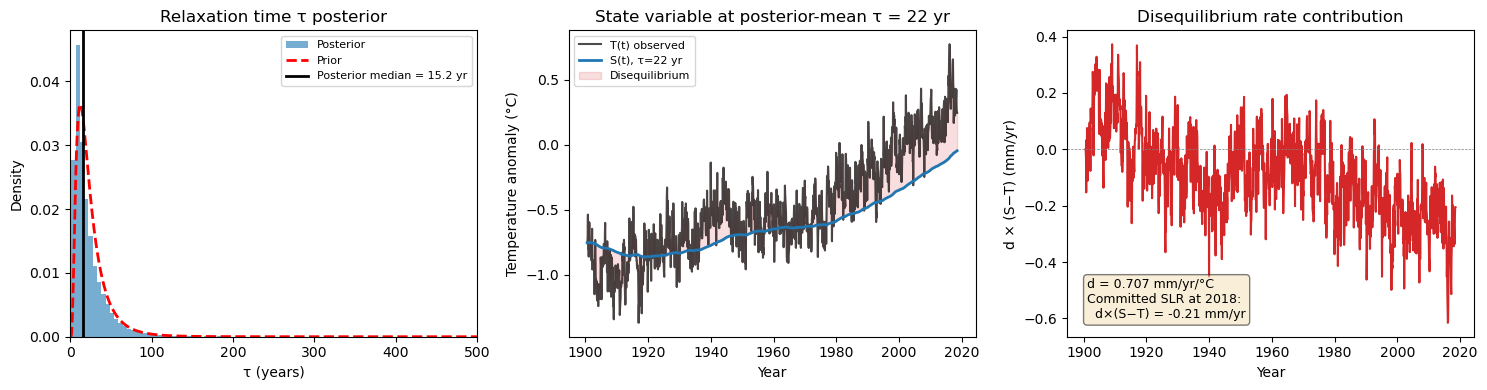

τ posterior: median = 15.2 yr, mean = 22.0 yr
  94% HDI: [3.9, 74.6] yr
d posterior mean: 0.707 mm/yr/°C
Disequilibrium at 2018: d×(S−T) = -0.21 mm/yr
  (≈ committed SLR not yet realised)


In [11]:
# ============================================================
# τ posterior
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# τ histogram with prior overlay
ax = axes[0]
tau_post = state_result.tau_posterior
ax.hist(tau_post[tau_post < 500], bins=80, density=True, alpha=0.6,
        color='C0', label='Posterior')
# Prior
tau_grid = np.linspace(0.1, 500, 1000)
log_tau_grid = np.log(tau_grid)
prior_pdf = (1.0 / (tau_grid * PRIOR_LOG_TAU_SIGMA * np.sqrt(2*np.pi)) *
             np.exp(-0.5 * ((log_tau_grid - PRIOR_LOG_TAU_MEAN) /
                            PRIOR_LOG_TAU_SIGMA)**2))
ax.plot(tau_grid, prior_pdf, 'r--', lw=2, label='Prior')
ax.axvline(np.median(tau_post), color='k', ls='-', lw=2,
           label=f'Posterior median = {np.median(tau_post):.1f} yr')
ax.set_xlabel('\u03c4 (years)')
ax.set_ylabel('Density')
ax.set_title('Relaxation time \u03c4 posterior')
ax.legend(fontsize=8)
ax.set_xlim(0, 500)

# S(t) vs T(t) at posterior-mean τ
# state_variable_mean was computed on the extended grid (time_monthly_ext),
# so truncate to the observation period (time_monthly_fit) for plotting.
ax = axes[1]
tau_mean = state_result.design_info['tau_mean']
n_fit = len(time_monthly_fit)
S_mean_fit = state_result.state_variable_mean[:n_fit]
ax.plot(time_monthly_fit, T_monthly_fit, 'k-', lw=1.5, alpha=0.7,
        label='T(t) observed')
ax.plot(time_monthly_fit, S_mean_fit, '-',
        color='C0', lw=2, label=f'S(t), \u03c4={tau_mean:.0f} yr')
ax.fill_between(time_monthly_fit,
                T_monthly_fit, S_mean_fit,
                alpha=0.15, color='C3', label='Disequilibrium')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (\u00b0C)')
ax.set_title(f'State variable at posterior-mean \u03c4 = {tau_mean:.0f} yr')
ax.legend(fontsize=8)

# Disequilibrium contribution d·(S-T) in mm/yr
ax = axes[2]
d_mean = state_result.physical_coefficients[3]  # meters
diseq = S_mean_fit - T_monthly_fit
diseq_rate = d_mean * diseq * M_TO_MM
ax.plot(time_monthly_fit, diseq_rate, 'C3-', lw=1.5)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('d \u00d7 (S\u2212T) (mm/yr)')
ax.set_title('Disequilibrium rate contribution')
ax.text(0.05, 0.05,
        f'd = {d_mean*M_TO_MM:.3f} mm/yr/\u00b0C\n'
        f'Committed SLR at 2018:\n'
        f'  d\u00d7(S\u2212T) = {diseq_rate[-1]:.2f} mm/yr',
        transform=ax.transAxes, fontsize=9, va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_tau_analysis.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'\u03c4 posterior: median = {np.median(tau_post):.1f} yr, '
      f'mean = {np.mean(tau_post):.1f} yr')
print(f'  94% HDI: [{np.percentile(tau_post, 3):.1f}, '
      f'{np.percentile(tau_post, 97):.1f}] yr')
print(f'd posterior mean: {d_mean*M_TO_MM:.3f} mm/yr/\u00b0C')
print(f'Disequilibrium at 2018: d\u00d7(S\u2212T) = {diseq_rate[-1]:.2f} mm/yr')
print(f'  (\u2248 committed SLR not yet realised)')

## 8. Limiting Behaviour: $\tau \to 0$ Recovery

Compare the rate-and-state model with the instantaneous model (already fitted in §5). If $d \approx 0$ and $\tau$ is unconstrained, the data do not require the state variable — the 1900–2018 record cannot distinguish the two models. This is itself an informative finding: the effective response timescale is either short enough to be captured by the instantaneous model, or the observational record is too short to identify it.

In [12]:
# ============================================================
# Comparison: Instantaneous vs Rate-and-State
# (inst_result already computed in cell-011)
# ============================================================
print('=' * 75)
print('Comparison: Instantaneous vs Rate-and-State (mm/yr)')
print('=' * 75)
labels = ['dα/dT', 'α₀', 'trend']
print(f'{"Parameter":<14} {"Instantaneous [94% HDI]":>30} {"State model [94% HDI]":>30}')
print('-' * 75)
for k, lab in enumerate(labels):
    v_inst = inst_result.physical_coefficients[k] * M_TO_MM
    hdi_inst = inst_result.physical_hdi_94[k] * M_TO_MM
    v_state = state_result.physical_coefficients[k] * M_TO_MM
    hdi_state = state_result.physical_hdi_94[k] * M_TO_MM
    print(f'{lab:<14} {v_inst:7.3f}  [{hdi_inst[0]:.3f}, {hdi_inst[1]:.3f}]'
          f'  {v_state:7.3f}  [{hdi_state[0]:.3f}, {hdi_state[1]:.3f}]')

d_val = state_result.physical_coefficients[3] * M_TO_MM
d_hdi = state_result.physical_hdi_94[3] * M_TO_MM
print(f'\n{"d (diseq)":<14} {"---":>30} {d_val:7.3f}  [{d_hdi[0]:.3f}, {d_hdi[1]:.3f}]')
print(f'\n{"τ (yr)":<14} {"→ 0 (by definition)":>30} '
      f'{np.median(state_result.tau_posterior):7.1f}  '
      f'[{np.percentile(state_result.tau_posterior, 3):.1f}, '
      f'{np.percentile(state_result.tau_posterior, 97):.1f}]')
print(f'\n{"R²":<14} {inst_result.r2:>30.4f} {state_result.r2:>30.4f}')
print(f'{"σ_extra (mm)":<14} '
      f'{np.median(inst_result.sigma_extra_posterior)*M_TO_MM:>30.2f} '
      f'{np.median(state_result.sigma_extra_posterior)*M_TO_MM:>30.2f}')

# Is d significantly > 0?
d_samples = state_result.posterior_samples[:, 3] * M_TO_MM
frac_positive = np.mean(d_samples > 0.01)
print(f'\nP(d > 0.01 mm/yr/°C) = {frac_positive:.3f}')
if frac_positive < 0.95:
    print('  → d is NOT significantly positive; data are consistent with d=0.')
    print('    The instantaneous model is sufficient for this observational record.')
else:
    print('  → d is significantly positive; the state variable improves the fit.')
    print('    The disequilibrium term captures delayed response not in the instantaneous model.')

Comparison: Instantaneous vs Rate-and-State (mm/yr)
Parameter             Instantaneous [94% HDI]          State model [94% HDI]
---------------------------------------------------------------------------
dα/dT            4.573  [3.090, 6.016]    4.565  [3.069, 6.077]
α₀               5.016  [3.978, 6.070]    5.192  [4.055, 6.332]
trend            2.509  [2.366, 2.649]    2.668  [2.377, 3.013]

d (diseq)                                 ---   0.707  [0.000, 1.926]

τ (yr)                    → 0 (by definition)    15.2  [3.9, 74.6]

R²                                     0.9696                         0.9677
σ_extra (mm)                             1.24                           1.30

P(d > 0.01 mm/yr/°C) = 0.986
  → d is significantly positive; the state variable improves the fit.
    The disequilibrium term captures delayed response not in the instantaneous model.


## 9. Model Fit and Residuals

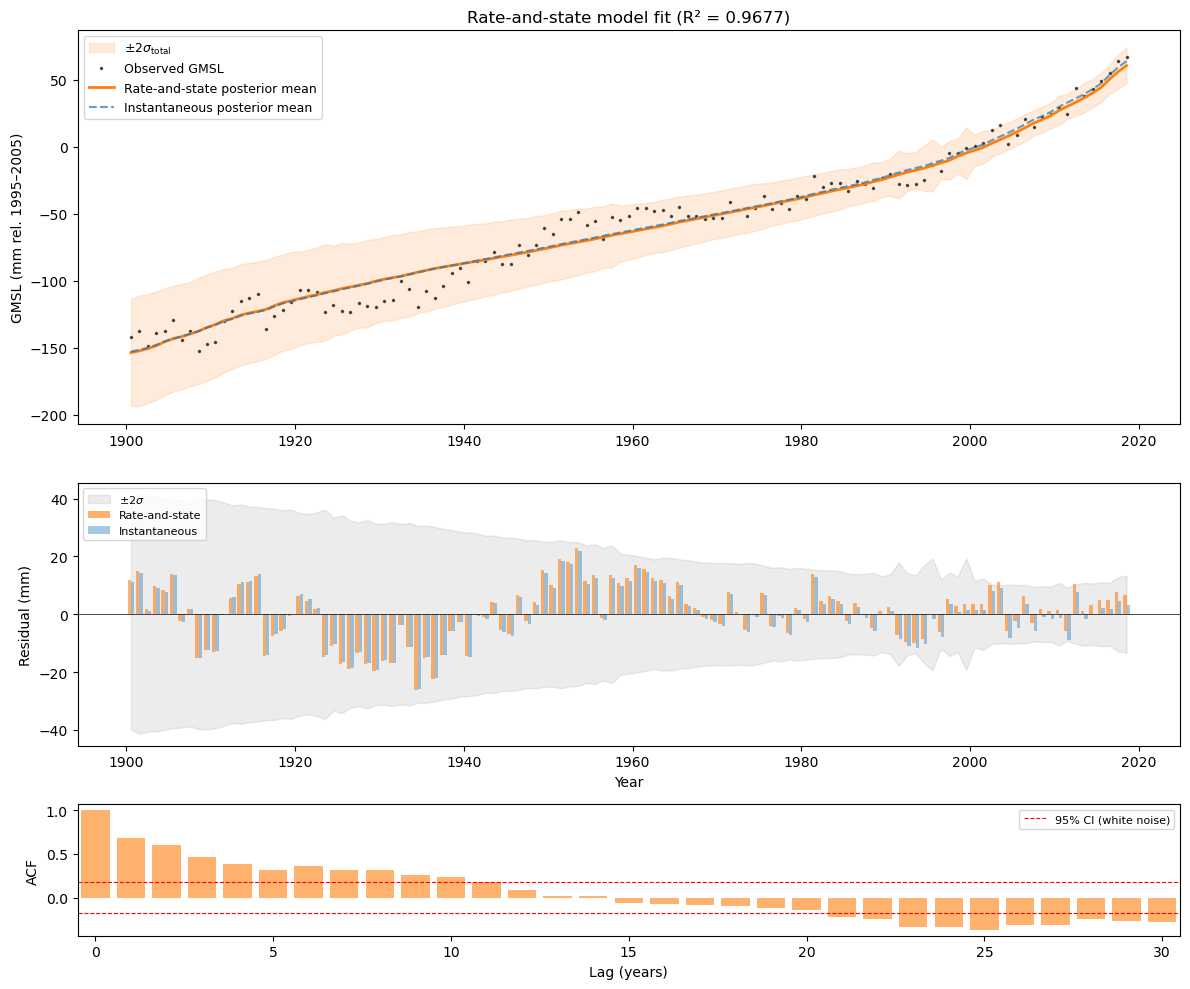

State model residual std:  9.86 mm
Instantaneous residual std: 9.57 mm
Points outside ±2σ: 2/119 (1.7%, expected ~5%)


In [13]:
# ============================================================
# Model fit: observed vs modeled GMSL
# ============================================================
sigma_extra_med = np.median(state_result.sigma_extra_posterior)
sigma_total = np.sqrt(sigma_obs_fixed**2 + sigma_extra_med**2)

fig, axes = plt.subplots(3, 1, figsize=(12, 10),
                         gridspec_kw={'height_ratios': [3, 2, 1]})

# Panel 1: Observed vs modeled
ax = axes[0]
ax.fill_between(obs_years,
                (state_result.H_model_mean - 2*sigma_total) * M_TO_MM,
                (state_result.H_model_mean + 2*sigma_total) * M_TO_MM,
                alpha=0.15, color='C1', label=r'$\pm 2\sigma_{\rm total}$')
ax.plot(obs_years, state_result.H_obs * M_TO_MM, 'k.', ms=3, alpha=0.6,
        label='Observed GMSL')
ax.plot(obs_years, state_result.H_model_mean * M_TO_MM, 'C1-', lw=2,
        label='Rate-and-state posterior mean')
# Instantaneous for comparison
ax.plot(obs_years, inst_result.H_model_mean * M_TO_MM, 'C0--', lw=1.5,
        alpha=0.7, label='Instantaneous posterior mean')
ax.set_ylabel('GMSL (mm rel. 1995–2005)')
ax.set_title(f'Rate-and-state model fit (R² = {state_result.r2:.4f})')
ax.legend(loc='upper left', fontsize=9)

# Panel 2: Residuals (share x-axis with panel 1 only)
ax = axes[1]
axes[1].sharex(axes[0])
resid_mm = state_result.residuals * M_TO_MM
resid_inst_mm = inst_result.residuals * M_TO_MM
ax.fill_between(obs_years, -2*sigma_total*M_TO_MM, 2*sigma_total*M_TO_MM,
                alpha=0.15, color='gray', label=r'$\pm 2\sigma$')
ax.bar(obs_years - 0.2, resid_mm, width=0.4, color='C1', alpha=0.6,
       label='Rate-and-state')
ax.bar(obs_years + 0.2, resid_inst_mm, width=0.4, color='C0', alpha=0.4,
       label='Instantaneous')
ax.axhline(0, color='k', ls='-', lw=0.5)
ax.set_ylabel('Residual (mm)')
ax.set_xlabel('Year')
ax.legend(fontsize=8, loc='upper left')

# Panel 3: Residual ACF (independent x-axis: lag in years)
ax = axes[2]
maxlag = min(30, len(resid_mm) - 1)
acf_r = np.correlate(resid_mm - resid_mm.mean(),
                     resid_mm - resid_mm.mean(), mode='full')
acf_r = acf_r[len(acf_r)//2:]
acf_r /= acf_r[0]
ax.bar(range(maxlag + 1), acf_r[:maxlag + 1], color='C1', alpha=0.6)
ci_95 = 1.96 / np.sqrt(len(resid_mm))
ax.axhline(ci_95, color='red', ls='--', lw=0.8, label='95% CI (white noise)')
ax.axhline(-ci_95, color='red', ls='--', lw=0.8)
ax.set_xlabel('Lag (years)')
ax.set_ylabel('ACF')
ax.set_xlim(-0.5, maxlag + 0.5)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_fit_residuals.png', dpi=150,
            bbox_inches='tight')
plt.show()

print(f'State model residual std:  {np.std(resid_mm):.2f} mm')
print(f'Instantaneous residual std: {np.std(resid_inst_mm):.2f} mm')
n_outside = np.sum(np.abs(resid_mm) > 2*sigma_total*M_TO_MM)
print(f'Points outside ±2σ: {n_outside}/{len(resid_mm)} '
      f'({100*n_outside/len(resid_mm):.1f}%, expected ~5%)')

## 10. Prior Sensitivity: Exponential (PC) Prior on Acceleration

The quadratic coefficient $a$ controls how much the SLR rate accelerates with temperature. The integral regressors $I_2$ and $I_1$ are highly collinear, so many $(a, b, c)$ combinations fit the historical GMSL equally well but produce wildly different extrapolated rates.

**Penalised-complexity (PC) prior.** We use an Exponential prior on $a$, which acts as a PC prior (Simpson et al. 2017):
$$
a \sim \text{Exponential}(\mu_a), \quad p(a) = \frac{1}{\mu_a} \exp\!\left(-\frac{a}{\mu_a}\right)
$$

This has **maximum density at $a = 0$**, genuinely favouring the simpler order-1 model and requiring the data to provide evidence to pull $a$ away from zero. The Exponential mean $\mu_a$ is calibrated via a tail probability constraint:
$$
P(a > a_\text{thresh}) = p \quad\Longrightarrow\quad \mu_a = \frac{-a_\text{thresh}}{\ln p}
$$

**Why Exponential, not HalfNormal?** The HalfNormal prior is flat near zero — it does not distinguish $a = 0$ from $a = 0.5\sigma$, so it provides no genuine shrinkage toward the simpler model. The Exponential has its mode at zero and decays monotonically, providing genuine Bayesian model selection pressure toward order-1 while allowing the data to override this preference.

In [14]:
# ============================================================
# Prior sensitivity sweep over Exponential mean for a
# ============================================================

# Sweep over different Exponential means (in m/yr/°C²)
# Equivalent to varying the tail probability P(a > 5 mm/yr/°C²)
sweep_configs = [
    {'label': 'Strong (μ=1.0)',   'mu_a': 0.001},
    {'label': 'Default (μ=2.2)',  'mu_a': PRIOR_SCALE_A},  # calibrated
    {'label': 'Moderate (μ=3.5)', 'mu_a': 0.0035},
    {'label': 'Weak (μ=5.0)',     'mu_a': 0.005},
    {'label': 'Very weak (μ=10)', 'mu_a': 0.010},
]

# Show the tail probabilities
print('Exponential prior sensitivity sweep:')
print(f'  {"Config":<22} {"μ_a (mm/yr/°C²)":>16} {"P(a>3)":>8} {"P(a>5)":>8} {"P(a>10)":>8}')
print(f'  {"-"*66}')
for cfg in sweep_configs:
    mu = cfg['mu_a']
    p3 = np.exp(-0.003 / mu)
    p5 = np.exp(-0.005 / mu)
    p10 = np.exp(-0.010 / mu)
    print(f"  {cfg['label']:<22} {mu*M_TO_MM:16.2f} {p3:8.3f} {p5:8.3f} {p10:8.4f}")

# Run quick MCMC for each prior configuration
sweep_results = {}

for cfg in sweep_configs:
    print(f"\n{'='*60}")
    print(f"Running: {cfg['label']} "
          f"(μ_a = {cfg['mu_a']*M_TO_MM:.2f} mm/yr/°C²)")
    print(f"{'='*60}")

    result = fit_bayesian_level(
        H_obs=H_obs_full,
        sigma_obs=sigma_obs_fixed,
        I2_obs=I2_obs,
        I1_obs=I1_obs,
        I0_obs=I0_obs,
        prior_scale_a=cfg['mu_a'],
        prior_scale_b=PRIOR_SCALE_B,
        prior_c_mean=PRIOR_C_MEAN,
        prior_c_sigma=PRIOR_C_SIGMA,
        prior_sigma_extra_scale=PRIOR_SIGMA_EXTRA_SCALE,
        prior_H0_sigma=PRIOR_H0_SIGMA,
        n_samples=2000,
        n_walkers=32,
        n_burnin=500,
        progress=False,
        seed=42,
    )
    sweep_results[cfg['label']] = result

    a_mm = result.physical_coefficients[0] * M_TO_MM
    b_mm = result.physical_coefficients[1] * M_TO_MM
    c_mm = result.physical_coefficients[2] * M_TO_MM
    print(f"  a={a_mm:.3f}, b={b_mm:.3f}, c={c_mm:.3f} mm/yr, "
          f"R²={result.r2:.4f}")

print(f"\n{'='*60}")
print("Sweep complete.")

Exponential prior sensitivity sweep:
  Config                  μ_a (mm/yr/°C²)   P(a>3)   P(a>5)  P(a>10)
  ------------------------------------------------------------------
  Strong (μ=1.0)                     1.00    0.050    0.007   0.0000
  Default (μ=2.2)                    2.17    0.251    0.100   0.0100
  Moderate (μ=3.5)                   3.50    0.424    0.240   0.0574
  Weak (μ=5.0)                       5.00    0.549    0.368   0.1353
  Very weak (μ=10)                  10.00    0.741    0.607   0.3679

Running: Strong (μ=1.0) (μ_a = 1.00 mm/yr/°C²)
  a=4.285, b=4.760, c=2.478 mm/yr, R²=0.9700

Running: Default (μ=2.2) (μ_a = 2.17 mm/yr/°C²)
  a=4.664, b=5.040, c=2.491 mm/yr, R²=0.9694

Running: Moderate (μ=3.5) (μ_a = 3.50 mm/yr/°C²)
  a=4.770, b=5.109, c=2.491 mm/yr, R²=0.9692

Running: Weak (μ=5.0) (μ_a = 5.00 mm/yr/°C²)
  a=4.845, b=5.150, c=2.488 mm/yr, R²=0.9691

Running: Very weak (μ=10) (μ_a = 10.00 mm/yr/°C²)
  a=4.897, b=5.189, c=2.491 mm/yr, R²=0.9690

Sweep comp

### Rate at End of Record and Projection Sensitivity

A key diagnostic: the model-implied GMSL rate at the end of the observation record (≈2018) should be consistent with the observed altimetry rate of ≈3.1–3.6 mm/yr. Disagreement indicates the $(a, b, c)$ decomposition is over- or under-attributing acceleration.

We also show how the quadratic prior affects projections at 2100 under SSP2-4.5 as a representative scenario. The projection uses `project_gmsl_ensemble()` with 2000 MC samples from each posterior.

Temperature at end of record (2019): T = 0.244 °C
Observed GMSL rate at 2019:
  Satellite-era quadratic: 3.94 ± 0.75 mm/yr
  Kinematics (20 yr):      6.50 ± 0.82 mm/yr

Config                       a       b       c rate(T_end)  rate(4°C)      R²
---------------------------------------------------------------------------
Strong (μ=1.0)            4.28    4.76    2.48        3.89       90.1  0.9700
Default (μ=2.2)           4.66    5.04    2.49        4.00       97.3  0.9694
Moderate (μ=3.5)          4.77    5.11    2.49        4.02       99.3  0.9692
Weak (μ=5.0)              4.84    5.15    2.49        4.03      100.6  0.9691
Very weak (μ=10)          4.90    5.19    2.49        4.05      101.6  0.9690

Projection at 2100, SSP2-4.5 (mm rel. 2005)
Config                   Median             5–95% CI
----------------------------------------------------
Strong (μ=1.0)             1224 [    959,    1475]
Default (μ=2.2)            1304 [   1046,    1569]
Moderate (μ=3.5)           1323 [ 

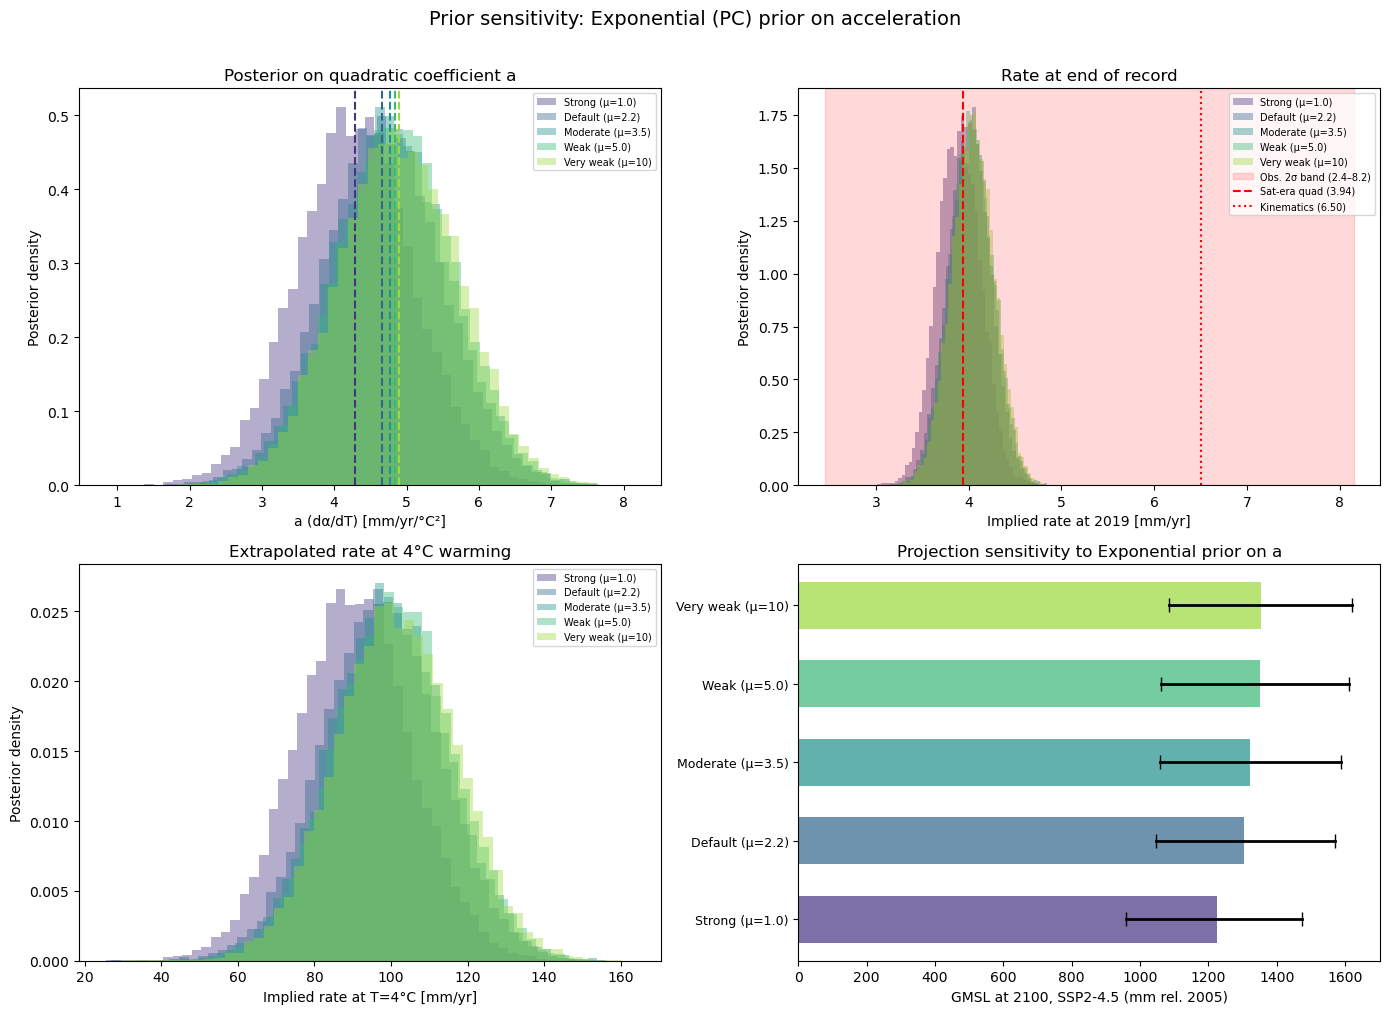

In [15]:
# ============================================================
# Rate diagnostic and projection sensitivity
# ============================================================
T_end = T_monthly_fit[-1]  # temperature at end of record
yr_end = obs_years[-1]

# Observed rates from satellite-era quadratic fit and kinematics
obs_rate_quad = sat_quad.rate * M_TO_MM          # mm/yr
obs_rate_quad_se = sat_quad.rate_se * M_TO_MM
idx_kin_end = np.argmin(np.abs(kin.time - yr_end))
obs_rate_kin = kin.rate[idx_kin_end] * M_TO_MM   # mm/yr
obs_rate_kin_se = kin.rate_se[idx_kin_end] * M_TO_MM

# 2σ band spanning both estimates
obs_rate_lo = min(obs_rate_quad - 2 * obs_rate_quad_se,
                  obs_rate_kin - 2 * obs_rate_kin_se)
obs_rate_hi = max(obs_rate_quad + 2 * obs_rate_quad_se,
                  obs_rate_kin + 2 * obs_rate_kin_se)

# Compute rate at end-of-record and quick projection for each prior
print(f'Temperature at end of record ({yr_end:.0f}): T = {T_end:.3f} °C')
print(f'Observed GMSL rate at {sat_quad.eval_time:.0f}:')
print(f'  Satellite-era quadratic: {obs_rate_quad:.2f} ± {obs_rate_quad_se:.2f} mm/yr')
print(f'  Kinematics (20 yr):      {obs_rate_kin:.2f} ± {obs_rate_kin_se:.2f} mm/yr')
print()
print(f'{"Config":<22} {"a":>7} {"b":>7} {"c":>7} '
      f'{"rate(T_end)":>11} {"rate(4°C)":>10} {"R²":>7}')
print('-' * 75)

for cfg in sweep_configs:
    res = sweep_results[cfg['label']]
    a, b, c = res.physical_coefficients * M_TO_MM
    rate_end = a * T_end**2 + b * T_end + c
    rate_4C = a * 16 + b * 4 + c
    print(f"{cfg['label']:<22} {a:7.2f} {b:7.2f} {c:7.2f} "
          f"{rate_end:11.2f} {rate_4C:10.1f} {res.r2:7.4f}")

# --- Quick projections for SSP2-4.5 ---
ssp_proj = 'SSP2-4.5'
proj_2100 = {}

for cfg in sweep_configs:
    res = sweep_results[cfg['label']]
    mc = project_gmsl_ensemble(
        coefficients=res.physical_coefficients,
        coefficients_cov=res.physical_covariance,
        temperature_projections=temp_projections,
        baseline_year=BASELINE_YEAR,
        baseline_gmsl=0.0,
        n_samples=2000,
        posterior_samples=res.posterior_samples,
        seed=42,
    )
    df = mc['scenarios'][ssp_proj]
    idx_2100 = np.argmin(np.abs(df['decimal_year'].values - 2100))
    proj_2100[cfg['label']] = {
        'median': df['gmsl'].iloc[idx_2100] * M_TO_MM,
        'p5': df['gmsl_lower'].iloc[idx_2100] * M_TO_MM,
        'p95': df['gmsl_upper'].iloc[idx_2100] * M_TO_MM,
    }

print(f'\n{"="*60}')
print(f'Projection at 2100, {ssp_proj} (mm rel. 2005)')
print(f'{"="*60}')
print(f'{"Config":<22} {"Median":>8} {"5–95% CI":>20}')
print('-' * 52)
for cfg in sweep_configs:
    p = proj_2100[cfg['label']]
    print(f"{cfg['label']:<22} {p['median']:8.0f} "
          f"[{p['p5']:7.0f}, {p['p95']:7.0f}]")

# --- Figure: 4-panel summary ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_sweep = plt.cm.viridis(np.linspace(0.15, 0.85, len(sweep_configs)))

# Panel 1: Posterior on a for each prior
ax = axes[0, 0]
for cfg, col in zip(sweep_configs, colors_sweep):
    res = sweep_results[cfg['label']]
    a_samples = res.posterior_samples[:, 0] * M_TO_MM
    ax.hist(a_samples, bins=50, alpha=0.4, color=col, density=True,
            label=cfg['label'])
    ax.axvline(res.physical_coefficients[0]*M_TO_MM, color=col, ls='--',
               lw=1.5)
ax.set_xlabel('a (dα/dT) [mm/yr/°C²]')
ax.set_ylabel('Posterior density')
ax.set_title('Posterior on quadratic coefficient a')
ax.legend(fontsize=7, loc='upper right')

# Panel 2: Rate at end-of-record using posterior samples
ax = axes[0, 1]
for cfg, col in zip(sweep_configs, colors_sweep):
    res = sweep_results[cfg['label']]
    a_s, b_s, c_s = (res.posterior_samples * M_TO_MM).T
    rate_samples = a_s * T_end**2 + b_s * T_end + c_s
    ax.hist(rate_samples, bins=50, alpha=0.4, color=col, density=True,
            label=cfg['label'])
# Observed rate band (from satellite-era quadratic and kinematics)
ax.axvspan(obs_rate_lo, obs_rate_hi, alpha=0.15, color='red',
           label=f'Obs. 2σ band ({obs_rate_lo:.1f}–{obs_rate_hi:.1f})')
ax.axvline(obs_rate_quad, color='red', ls='--', lw=1.5,
           label=f'Sat-era quad ({obs_rate_quad:.2f})')
ax.axvline(obs_rate_kin, color='red', ls=':', lw=1.5,
           label=f'Kinematics ({obs_rate_kin:.2f})')
ax.set_xlabel(f'Implied rate at {yr_end:.0f} [mm/yr]')
ax.set_ylabel('Posterior density')
ax.set_title('Rate at end of record')
ax.legend(fontsize=7, loc='upper right')

# Panel 3: Rate at 4°C warming
ax = axes[1, 0]
for cfg, col in zip(sweep_configs, colors_sweep):
    res = sweep_results[cfg['label']]
    a_s, b_s, c_s = (res.posterior_samples * M_TO_MM).T
    rate_4C_samples = a_s * 16 + b_s * 4 + c_s
    ax.hist(rate_4C_samples, bins=50, alpha=0.4, color=col, density=True,
            label=cfg['label'])
ax.set_xlabel('Implied rate at T=4°C [mm/yr]')
ax.set_ylabel('Posterior density')
ax.set_title('Extrapolated rate at 4°C warming')
ax.legend(fontsize=7, loc='upper right')

# Panel 4: Projection at 2100 (SSP2-4.5)
ax = axes[1, 1]
labels_plot = [cfg['label'] for cfg in sweep_configs]
medians = [proj_2100[l]['median'] for l in labels_plot]
p5s = [proj_2100[l]['p5'] for l in labels_plot]
p95s = [proj_2100[l]['p95'] for l in labels_plot]
y_pos = np.arange(len(labels_plot))
ax.barh(y_pos, medians, color=[c for c in colors_sweep], alpha=0.7,
        height=0.6)
for i in range(len(labels_plot)):
    ax.plot([p5s[i], p95s[i]], [y_pos[i], y_pos[i]], 'k-', lw=2)
    ax.plot([p5s[i], p95s[i]], [y_pos[i], y_pos[i]], 'k|', ms=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_plot, fontsize=9)
ax.set_xlabel(f'GMSL at 2100, {ssp_proj} (mm rel. 2005)')
ax.set_title(f'Projection sensitivity to Exponential prior on a')

plt.suptitle('Prior sensitivity: Exponential (PC) prior on acceleration',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_prior_sensitivity.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 11. Forward Projections

Project GMSL under SSP scenarios using the joint posterior samples of $(a, b, c, d, \tau)$. Historical temperature is prepended for ODE spin-up so the state variable has the correct initial condition at the start of each projection.

In [16]:
# ============================================================
# Rate-and-state projections
# ============================================================
mc_state = project_gmsl_state_ensemble(
    coefficients=state_result.physical_coefficients,
    coefficients_cov=state_result.physical_covariance,
    tau_samples=state_result.tau_posterior,
    temperature_projections=temp_projections,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    posterior_samples=state_result.posterior_samples,
    seed=42,
)

# Instantaneous projections for comparison
mc_inst = project_gmsl_ensemble(
    coefficients=inst_result.physical_coefficients,
    coefficients_cov=inst_result.physical_covariance,
    temperature_projections=temp_projections,
    baseline_year=BASELINE_YEAR,
    baseline_gmsl=0.0,
    n_samples=2000,
    posterior_samples=inst_result.posterior_samples,
    seed=42,
)

# Summary table
print('=' * 85)
print('Projection comparison at 2050, 2100, 2150 (mm rel. 2005)')
print('=' * 85)
for yr in [2050, 2100, 2150]:
    print(f'\n--- Year {yr} ---')
    print(f'{"SSP":<12} {"State med [5\u201395%]":>26} {"Instant. med [5\u201395%]":>26}')
    print('-' * 66)
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        # State model
        df_s = mc_state['scenarios'][ssp]
        idx_s = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        g_s = df_s['gmsl'].iloc[idx_s] * M_TO_MM
        lo_s = df_s['gmsl_lower'].iloc[idx_s] * M_TO_MM
        hi_s = df_s['gmsl_upper'].iloc[idx_s] * M_TO_MM
        s_str = f'{g_s:6.0f}  [{lo_s:5.0f}, {hi_s:5.0f}]'

        # Instantaneous
        df_i = mc_inst['scenarios'][ssp]
        idx_i = np.argmin(np.abs(df_i['decimal_year'].values - yr))
        g_i = df_i['gmsl'].iloc[idx_i] * M_TO_MM
        lo_i = df_i['gmsl_lower'].iloc[idx_i] * M_TO_MM
        hi_i = df_i['gmsl_upper'].iloc[idx_i] * M_TO_MM
        i_str = f'{g_i:6.0f}  [{lo_i:5.0f}, {hi_i:5.0f}]'

        print(f'{ssp:<12} {s_str:>26} {i_str:>26}')

Projection comparison at 2050, 2100, 2150 (mm rel. 2005)

--- Year 2050 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
------------------------------------------------------------------
SSP1-2.6            254  [  213,   289]        252  [  215,   288]
SSP2-4.5            279  [  231,   320]        277  [  234,   319]
SSP3-7.0            301  [  248,   348]        300  [  251,   348]
SSP5-8.5            347  [  281,   403]        346  [  285,   405]

--- Year 2100 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
------------------------------------------------------------------
SSP1-2.6            785  [  647,   905]        771  [  642,   897]
SSP2-4.5           1312  [ 1029,  1555]       1300  [ 1034,  1554]
SSP3-7.0           2007  [ 1523,  2423]       1999  [ 1549,  2430]
SSP5-8.5           2784  [ 2077,  3396]       2778  [ 2120,  3410]

--- Year 2150 ---
SSP                   State med [5–95%]       Instant. med [5–95%]
---------------

## 12. Projection Comparison

Multi-panel comparison: rate-and-state vs instantaneous vs IPCC AR6.

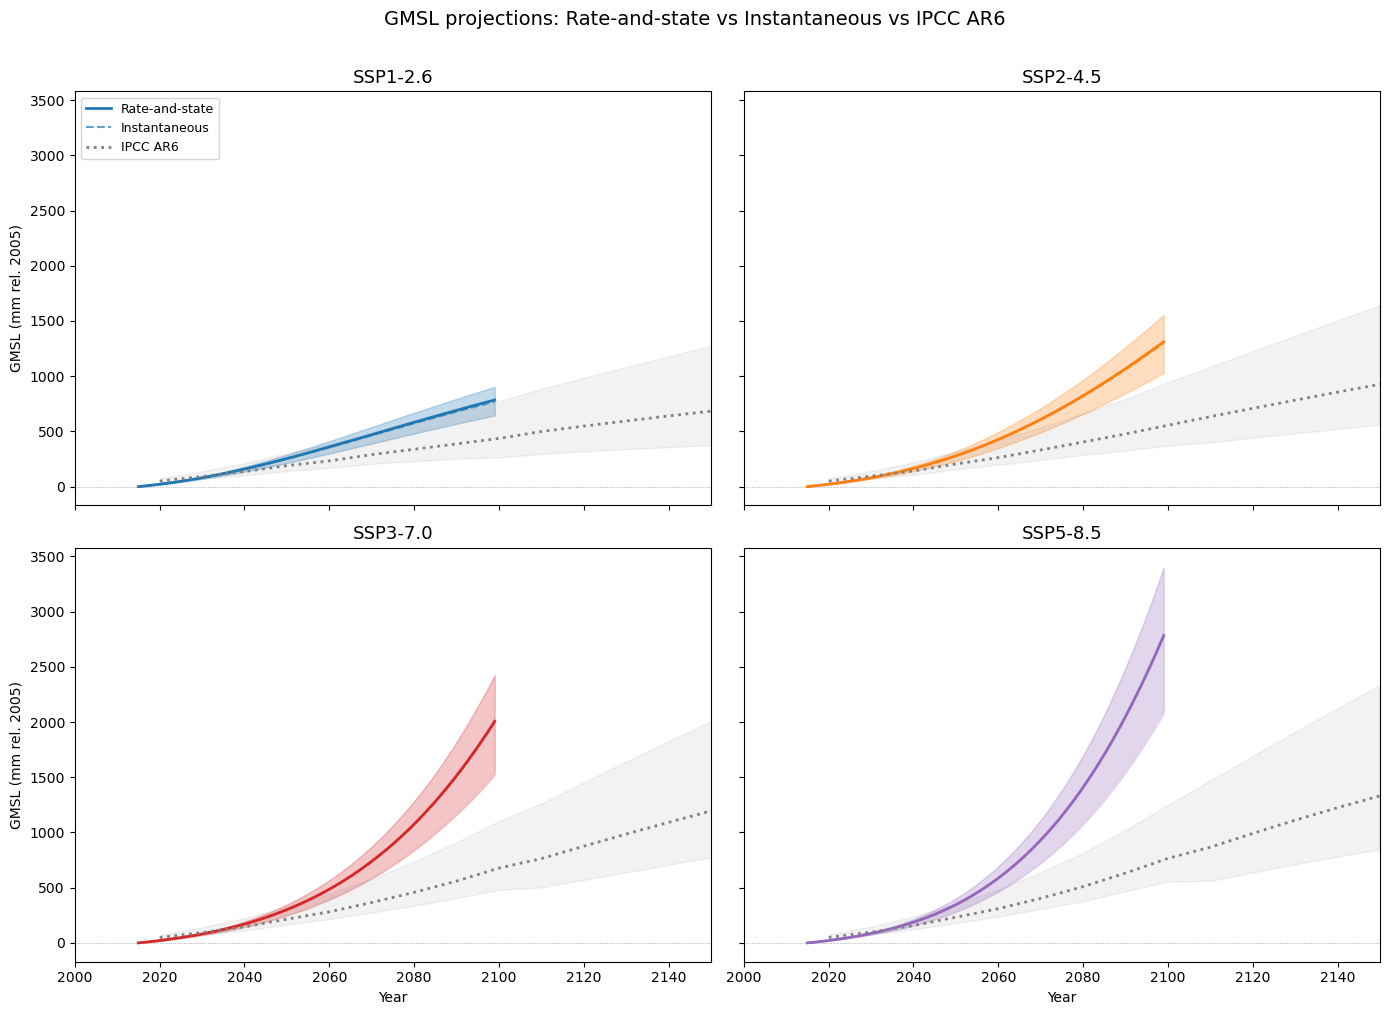

In [17]:
# ============================================================
# Multi-panel projection comparison
# ============================================================
ssp_colors = {
    'SSP1-2.6': 'C0', 'SSP2-4.5': 'C1',
    'SSP3-7.0': 'C3', 'SSP5-8.5': 'C4',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, ssp in zip(axes.flat,
                    ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']):
    color = ssp_colors[ssp]

    # State model
    df_s = mc_state['scenarios'][ssp]
    t_s = df_s['decimal_year'].values
    ax.fill_between(t_s, df_s['gmsl_lower']*M_TO_MM,
                    df_s['gmsl_upper']*M_TO_MM,
                    alpha=0.2, color=color)
    ax.plot(t_s, df_s['gmsl']*M_TO_MM, '-', color=color, lw=2,
            label='Rate-and-state')

    # Instantaneous
    df_i = mc_inst['scenarios'][ssp]
    t_i = df_i['decimal_year'].values
    ax.plot(t_i, df_i['gmsl']*M_TO_MM, '--', color=color, lw=1.5,
            alpha=0.7, label='Instantaneous')
    ax.fill_between(t_i, df_i['gmsl_lower']*M_TO_MM,
                    df_i['gmsl_upper']*M_TO_MM,
                    alpha=0.08, color=color)

    # IPCC
    if ssp in ipcc_gmsl:
        ipcc = ipcc_gmsl[ssp]
        ipcc_t = np.array([
            t.year + (t.month - 0.5) / 12 for t in ipcc.index
        ])
        if 'gmsl' in ipcc.columns:
            ax.plot(ipcc_t, ipcc['gmsl'].values*M_TO_MM, ':',
                    color='gray', lw=2, label='IPCC AR6')
            if 'gmsl_lower' in ipcc.columns:
                ax.fill_between(ipcc_t,
                                ipcc['gmsl_lower'].values*M_TO_MM,
                                ipcc['gmsl_upper'].values*M_TO_MM,
                                alpha=0.1, color='gray')

    ax.set_title(ssp, fontsize=13)
    ax.axhline(0, color='gray', ls=':', lw=0.5)
    if ax in axes[1]:
        ax.set_xlabel('Year')
    if ax in axes[:, 0]:
        ax.set_ylabel('GMSL (mm rel. 2005)')

axes[0, 0].legend(fontsize=9, loc='upper left')
axes[0, 0].set_xlim(2000, 2150)
plt.suptitle('GMSL projections: Rate-and-state vs Instantaneous vs IPCC AR6',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_projections.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 13. $\tau$ Sensitivity Analysis

τ Sensitivity: GMSL at 2100 (mm rel. 2005)
scenario  SSP1-2.6  SSP2-4.5  SSP3-7.0  SSP5-8.5
tau                                             
1              807      1347      2052      2839
10             803      1345      2048      2838
30             773      1296      1996      2776
50             776      1302      1998      2782
100            747      1273      1966      2746
200            722      1233      1927      2701
500            702      1216      1905      2672


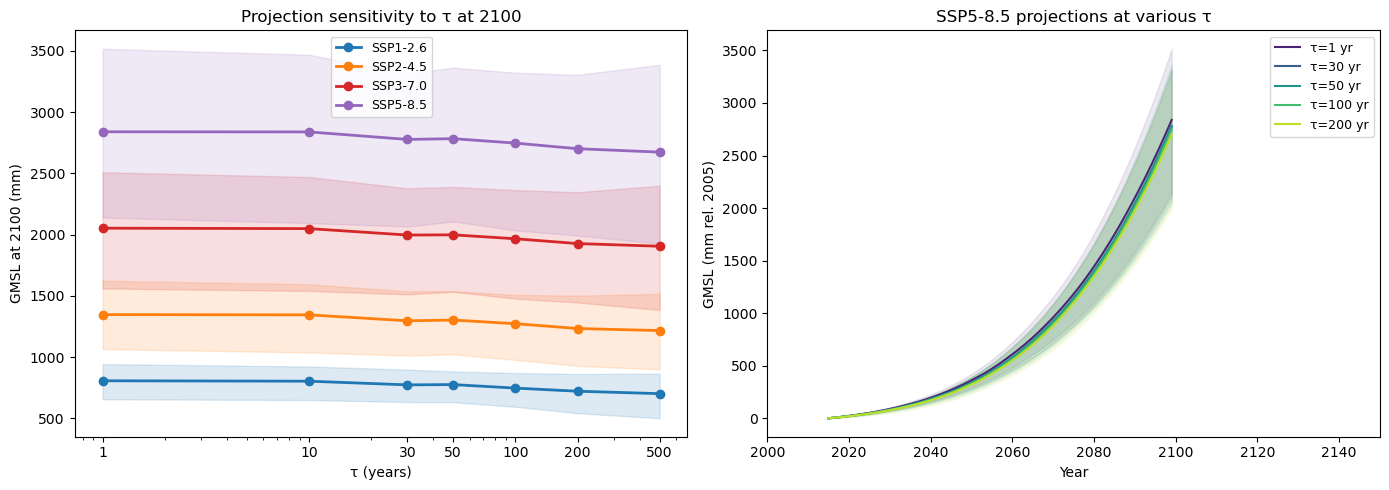

In [18]:
# ============================================================
# τ sensitivity
# ============================================================

ssp_colors = {
    'SSP1-2.6': 'C0', 'SSP2-4.5': 'C1',
    'SSP3-7.0': 'C3', 'SSP5-8.5': 'C4',
}

tau_test_values = np.array([1, 10, 30, 50, 100, 200, 500])

tau_sens = project_gmsl_tau_sensitivity(
    coefficients=state_result.physical_coefficients,
    coefficients_cov=state_result.physical_covariance,
    tau_values=tau_test_values,
    temperature_projections=temp_projections,
    historical_temperature=T_monthly_all,
    historical_time=time_monthly_all,
    baseline_year=BASELINE_YEAR,
    n_samples=500,
    posterior_samples=state_result.posterior_samples,
    seed=42,
)

# ---- Summary table ----
summary_df = tau_sens['summary']
print('=' * 80)
print('\u03c4 Sensitivity: GMSL at 2100 (mm rel. 2005)')
print('=' * 80)
pivot = summary_df[summary_df['year'] == 2100].pivot(
    index='tau', columns='scenario', values='gmsl_median'
) * M_TO_MM
print(pivot.to_string(float_format='{:.0f}'.format))

# ---- Line plot: GMSL at 2100 vs τ for each SSP ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    mask = (summary_df['scenario'] == ssp) & (summary_df['year'] == 2100)
    sub = summary_df[mask].sort_values('tau')
    ax.plot(sub['tau'], sub['gmsl_median']*M_TO_MM, 'o-',
            color=ssp_colors[ssp], lw=2, label=ssp)
    ax.fill_between(sub['tau'], sub['gmsl_lower']*M_TO_MM,
                    sub['gmsl_upper']*M_TO_MM,
                    alpha=0.15, color=ssp_colors[ssp])
ax.set_xlabel('\u03c4 (years)')
ax.set_ylabel('GMSL at 2100 (mm)')
ax.set_title('Projection sensitivity to \u03c4 at 2100')
ax.legend(fontsize=9)
ax.set_xscale('log')
ax.set_xticks(tau_test_values)
ax.set_xticklabels(tau_test_values)

# Full time series for SSP5-8.5 at different τ
ax = axes[1]
for tau_val, col in zip([1, 30, 50, 100, 200],
                         plt.cm.viridis(np.linspace(0.1, 0.9, 5))):
    df_t = tau_sens[tau_val]['scenarios']['SSP5-8.5']
    ax.plot(df_t['decimal_year'], df_t['gmsl']*M_TO_MM, '-',
            color=col, lw=1.5, label=f'\u03c4={tau_val} yr')
    ax.fill_between(df_t['decimal_year'],
                    df_t['gmsl_lower']*M_TO_MM,
                    df_t['gmsl_upper']*M_TO_MM,
                    alpha=0.1, color=col)
ax.set_xlabel('Year')
ax.set_ylabel('GMSL (mm rel. 2005)')
ax.set_title('SSP5-8.5 projections at various \u03c4')
ax.legend(fontsize=9)
ax.set_xlim(2000, 2150)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_tau_sensitivity.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 14. Hierarchical DAG Framework

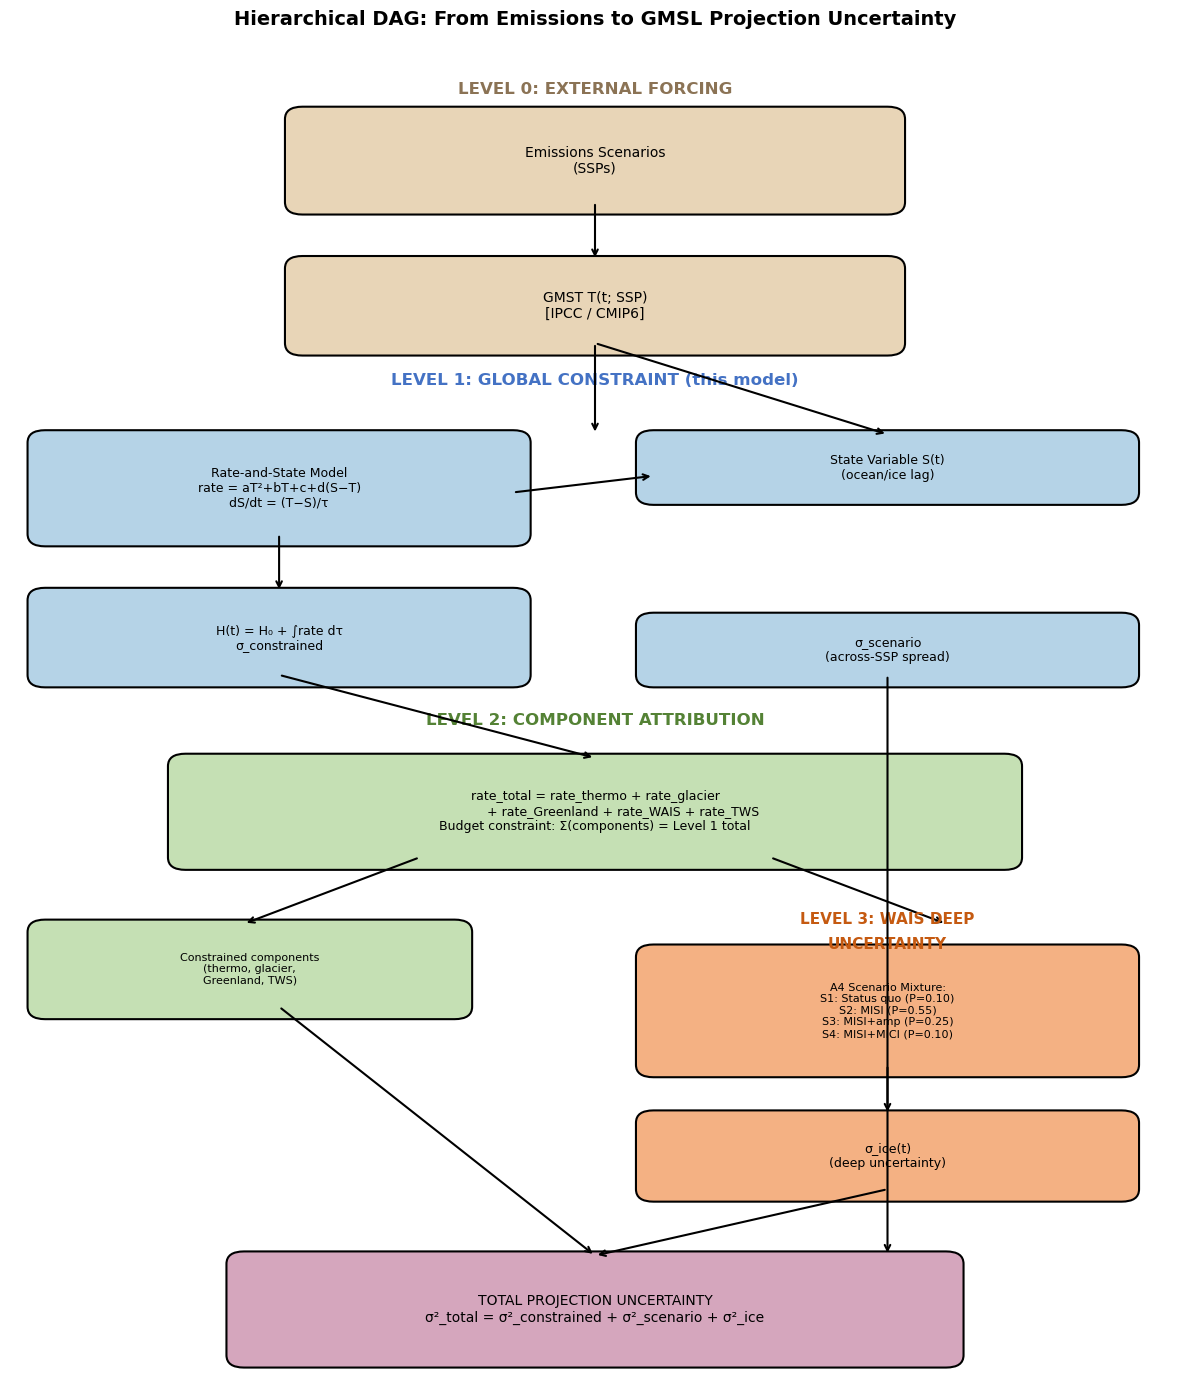

In [19]:
# ============================================================
# DAG figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 16)
ax.axis('off')

# Colours
c_l0 = '#E8D5B7'  # forcing
c_l1 = '#B5D3E7'  # global constraint
c_l2 = '#C5E0B4'  # component
c_l3 = '#F4B183'  # WAIS deep
c_total = '#D5A6BD' # total

def draw_box(ax, x, y, w, h, text, color, fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.15',
                                    facecolor=color, edgecolor='black', lw=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, **kwargs):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', lw=1.5,
                                color=kwargs.get('color', 'black')))

# Level 0: Forcing
ax.text(5, 15.5, 'LEVEL 0: EXTERNAL FORCING', ha='center',
        fontsize=12, fontweight='bold', color='#8B7355')
draw_box(ax, 2.5, 14.2, 5, 1.0, 'Emissions Scenarios\n(SSPs)', c_l0, 10)
draw_arrow(ax, 5, 14.2, 5, 13.5)
draw_box(ax, 2.5, 12.5, 5, 0.9, 'GMST T(t; SSP)\n[IPCC / CMIP6]', c_l0, 10)

# Level 1: Global constraint
ax.text(5, 12.0, 'LEVEL 1: GLOBAL CONSTRAINT (this model)', ha='center',
        fontsize=12, fontweight='bold', color='#4472C4')
draw_arrow(ax, 5, 12.5, 5, 11.4)
draw_box(ax, 0.3, 10.2, 4.0, 1.1,
         'Rate-and-State Model\nrate = aT\u00b2+bT+c+d(S\u2212T)\ndS/dt = (T\u2212S)/\u03c4',
         c_l1, 9)
draw_box(ax, 5.5, 10.7, 4.0, 0.6, 'State Variable S(t)\n(ocean/ice lag)', c_l1, 9)
draw_arrow(ax, 5, 12.5, 7.5, 11.4)
draw_arrow(ax, 4.3, 10.7, 5.5, 10.9)

draw_arrow(ax, 2.3, 10.2, 2.3, 9.5)
draw_box(ax, 0.3, 8.5, 4.0, 0.9, 'H(t) = H\u2080 + \u222brate d\u03c4\n\u03c3_constrained',
         c_l1, 9)

draw_box(ax, 5.5, 8.5, 4.0, 0.6, '\u03c3_scenario\n(across-SSP spread)', c_l1, 9)

# Level 2: Component attribution
ax.text(5, 7.9, 'LEVEL 2: COMPONENT ATTRIBUTION', ha='center',
        fontsize=12, fontweight='bold', color='#548235')
draw_arrow(ax, 2.3, 8.5, 5, 7.5)
draw_box(ax, 1.5, 6.3, 7.0, 1.1,
         'rate_total = rate_thermo + rate_glacier\n'
         '              + rate_Greenland + rate_WAIS + rate_TWS\n'
         'Budget constraint: \u03a3(components) = Level 1 total',
         c_l2, 9)

# Split to components
draw_arrow(ax, 3.5, 6.3, 2.0, 5.5)
draw_arrow(ax, 6.5, 6.3, 8.0, 5.5)

draw_box(ax, 0.3, 4.5, 3.5, 0.9,
         'Constrained components\n(thermo, glacier,\nGreenland, TWS)', c_l2, 8)

# Level 3: WAIS deep uncertainty
ax.text(7.5, 5.5, 'LEVEL 3: WAIS DEEP', ha='center',
        fontsize=11, fontweight='bold', color='#C55A11')
ax.text(7.5, 5.2, 'UNCERTAINTY', ha='center',
        fontsize=11, fontweight='bold', color='#C55A11')
draw_box(ax, 5.5, 3.8, 4.0, 1.3,
         'A4 Scenario Mixture:\nS1: Status quo (P=0.10)\n'
         'S2: MISI (P=0.55)\nS3: MISI+amp (P=0.25)\n'
         'S4: MISI+MICI (P=0.10)',
         c_l3, 8)

draw_arrow(ax, 7.5, 3.8, 7.5, 3.2)
draw_box(ax, 5.5, 2.3, 4.0, 0.8, '\u03c3_ice(t)\n(deep uncertainty)', c_l3, 9)

# Total
draw_arrow(ax, 2.3, 4.5, 5, 1.5)
draw_arrow(ax, 7.5, 2.3, 5, 1.5)
draw_arrow(ax, 7.5, 8.5, 7.5, 1.5)
draw_box(ax, 2.0, 0.3, 6, 1.1,
         'TOTAL PROJECTION UNCERTAINTY\n'
         '\u03c3\u00b2_total = \u03c3\u00b2_constrained + \u03c3\u00b2_scenario + \u03c3\u00b2_ice',
         c_total, 10)

ax.set_title('Hierarchical DAG: From Emissions to GMSL Projection Uncertainty',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_dag_framework.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 15. Variance Decomposition

Variance Decomposition (mm)
  Year   σ_constr   σ_scenario    σ_ice    σ_total
--------------------------------------------------
  2050       29.3         34.0     15.0       47.4
  2075       98.2        230.9     50.0      255.9
  2100      228.2        751.0    120.0      794.0
  2125      228.2        751.0    200.0      810.0
  2150      228.2        751.0    300.0      840.3


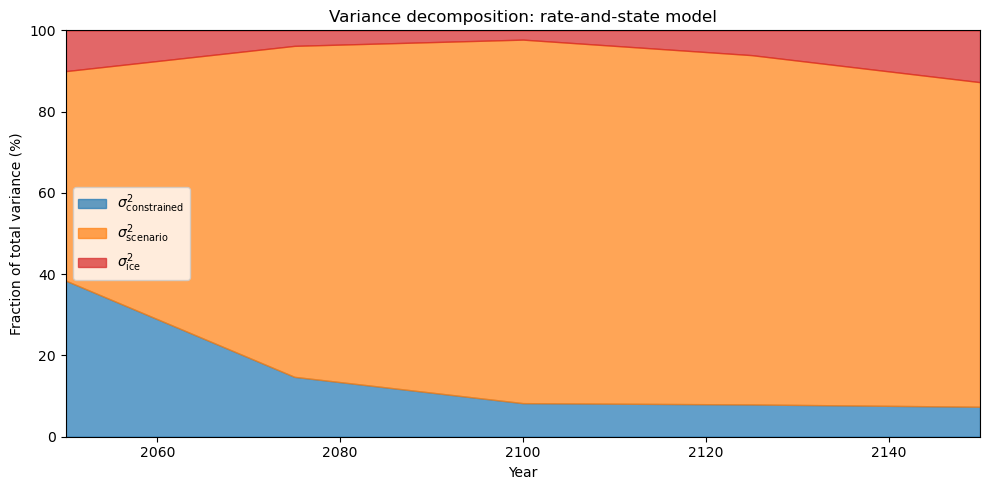

In [20]:
# ============================================================
# Variance decomposition
# ============================================================
target_years = [2050, 2075, 2100, 2125, 2150]

# σ_constrained: average within-scenario 5–95% range / 3.29
# (for Gaussian, 90% range ≈ 3.29σ)
sigma_constrained = {}
for yr in target_years:
    spreads = []
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        df_s = mc_state['scenarios'][ssp]
        idx = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        spread = (df_s['gmsl_upper'].iloc[idx] -
                  df_s['gmsl_lower'].iloc[idx]) * M_TO_MM
        spreads.append(spread)
    sigma_constrained[yr] = np.mean(spreads) / 3.29

# σ_scenario: std of medians across SSPs
sigma_scenario = {}
for yr in target_years:
    medians = []
    for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
        df_s = mc_state['scenarios'][ssp]
        idx = np.argmin(np.abs(df_s['decimal_year'].values - yr))
        medians.append(df_s['gmsl'].iloc[idx] * M_TO_MM)
    sigma_scenario[yr] = np.std(medians)

# σ_ice: from A4 framework (approximate values from predictability notebook)
# These are representative values; actual values should come from
# the predictability_analysis notebook's A4 calculation
sigma_ice_approx = {
    2050: 15, 2075: 50, 2100: 120, 2125: 200, 2150: 300,
}

print('=' * 70)
print('Variance Decomposition (mm)')
print('=' * 70)
print(f'{"Year":>6} {"\u03c3_constr":>10} {"\u03c3_scenario":>12} '
      f'{"\u03c3_ice":>8} {"\u03c3_total":>10}')
print('-' * 50)
for yr in target_years:
    sc = sigma_constrained[yr]
    ss = sigma_scenario[yr]
    si = sigma_ice_approx.get(yr, 0)
    st = np.sqrt(sc**2 + ss**2 + si**2)
    print(f'{yr:>6} {sc:10.1f} {ss:12.1f} {si:8.1f} {st:10.1f}')

# ---- Stacked area chart ----
fig, ax = plt.subplots(figsize=(10, 5))
yrs = np.array(target_years)
v_c = np.array([sigma_constrained[y]**2 for y in yrs])
v_s = np.array([sigma_scenario[y]**2 for y in yrs])
v_i = np.array([sigma_ice_approx.get(y, 0)**2 for y in yrs])
v_total = v_c + v_s + v_i

ax.fill_between(yrs, 0, v_c/v_total*100, alpha=0.7, color='C0',
                label=r'$\sigma^2_{\rm constrained}$')
ax.fill_between(yrs, v_c/v_total*100, (v_c+v_s)/v_total*100,
                alpha=0.7, color='C1',
                label=r'$\sigma^2_{\rm scenario}$')
ax.fill_between(yrs, (v_c+v_s)/v_total*100, 100,
                alpha=0.7, color='C3',
                label=r'$\sigma^2_{\rm ice}$')
ax.set_xlabel('Year')
ax.set_ylabel('Fraction of total variance (%)')
ax.set_title('Variance decomposition: rate-and-state model')
ax.legend(loc='center left')
ax.set_ylim(0, 100)
ax.set_xlim(yrs[0], yrs[-1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'ratestate_variance_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()

## 16. Summary and Export

In [21]:
# ============================================================
# Export results to JSON + npz (full time series for hybrid notebook)
# ============================================================
import json

state_summary = {
    'model': 'bayesian_rate_and_state',
    'description': 'Rate-and-state Bayesian level-space calibration '
                   'with relaxation time \u03c4',
    'calibration': {
        'n_obs': len(H_obs_full),
        'obs_range': [float(obs_years[0]), float(obs_years[-1])],
        'r_squared': float(state_result.r2),
        'coefficients_mm_yr': {
            'dalpha_dT': float(state_result.physical_coefficients[0] * M_TO_MM),
            'alpha0': float(state_result.physical_coefficients[1] * M_TO_MM),
            'trend': float(state_result.physical_coefficients[2] * M_TO_MM),
            'd_diseq': float(state_result.physical_coefficients[3] * M_TO_MM),
        },
        'hdi_94_mm_yr': {
            'dalpha_dT': [float(x) for x in state_result.physical_hdi_94[0] * M_TO_MM],
            'alpha0': [float(x) for x in state_result.physical_hdi_94[1] * M_TO_MM],
            'trend': [float(x) for x in state_result.physical_hdi_94[2] * M_TO_MM],
            'd_diseq': [float(x) for x in state_result.physical_hdi_94[3] * M_TO_MM],
        },
        'tau_yr': {
            'median': float(np.median(state_result.tau_posterior)),
            'hdi_94': [
                float(np.percentile(state_result.tau_posterior, 3)),
                float(np.percentile(state_result.tau_posterior, 97)),
            ],
        },
        'sigma_extra_mm': {
            'median': float(np.median(state_result.sigma_extra_posterior) * M_TO_MM),
            'hdi_94': [
                float(np.percentile(state_result.sigma_extra_posterior, 3) * M_TO_MM),
                float(np.percentile(state_result.sigma_extra_posterior, 97) * M_TO_MM),
            ],
        },
    },
    'priors': {
        'a': f'Exponential(mean={PRIOR_SCALE_A*M_TO_MM:.2f} mm/yr/C^2)',
        'b': f'HalfNormal(sigma={PRIOR_SCALE_B*M_TO_MM:.1f} mm/yr/C)',
        'c': f'Normal({PRIOR_C_MEAN*M_TO_MM:.1f}, {PRIOR_C_SIGMA*M_TO_MM:.1f} mm/yr)',
        'd': f'Exponential(mean={PRIOR_SCALE_D*M_TO_MM:.2f} mm/yr/C)',
        'tau': f'LogNormal(log({np.exp(PRIOR_LOG_TAU_MEAN):.0f}), {PRIOR_LOG_TAU_SIGMA})',
        'sigma_extra': f'HalfCauchy(0, {PRIOR_SIGMA_EXTRA_SCALE*M_TO_MM:.1f} mm)',
        'H0': f'Normal(H_obs[0], {PRIOR_H0_SIGMA*M_TO_MM:.1f} mm)',
    },
    'projections_at_2100_mm': {},
}

# Add projections
for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    df_s = mc_state['scenarios'][ssp]
    idx = np.argmin(np.abs(df_s['decimal_year'].values - 2100))
    state_summary['projections_at_2100_mm'][ssp] = {
        'median': float(df_s['gmsl'].iloc[idx] * M_TO_MM),
        'p5': float(df_s['gmsl_lower'].iloc[idx] * M_TO_MM),
        'p95': float(df_s['gmsl_upper'].iloc[idx] * M_TO_MM),
    }

# Save JSON
out_path = DATA_DIR / 'processed' / 'bayesian_ratestate_results.json'
with open(out_path, 'w') as f:
    json.dump(state_summary, f, indent=2)
print(f'Results saved to {out_path}')

# Save full projection time series as npz for use by hybrid_forecast notebook
npz_data = {}
for ssp in ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']:
    df_s = mc_state['scenarios'][ssp]
    ssp_key = ssp.replace('-', '_').replace('.', '_')  # e.g. SSP2_4_5
    npz_data[f'{ssp_key}_time'] = df_s['decimal_year'].values
    npz_data[f'{ssp_key}_gmsl_median'] = df_s['gmsl'].values       # meters
    npz_data[f'{ssp_key}_gmsl_lower'] = df_s['gmsl_lower'].values  # meters
    npz_data[f'{ssp_key}_gmsl_upper'] = df_s['gmsl_upper'].values  # meters
npz_path = DATA_DIR / 'processed' / 'bayesian_ratestate_projections.npz'
np.savez_compressed(npz_path, **npz_data)
print(f'Projection time series saved to {npz_path}')

# ---- Print summary ----
print('\n' + '=' * 70)
print('RATE-AND-STATE MODEL \u2014 SUMMARY')
print('=' * 70)
cal = state_summary['calibration']
print(f"\nCalibration ({cal['obs_range'][0]:.0f}\u2013"
      f"{cal['obs_range'][1]:.0f}, n={cal['n_obs']}):")
print(f"  R\u00b2 = {cal['r_squared']:.4f}")
for name in ['dalpha_dT', 'alpha0', 'trend', 'd_diseq']:
    v = cal['coefficients_mm_yr'][name]
    hdi = cal['hdi_94_mm_yr'][name]
    print(f'  {name}: {v:.3f} [{hdi[0]:.3f}, {hdi[1]:.3f}] mm/yr')
t = cal['tau_yr']
print(f"  \u03c4: {t['median']:.1f} [{t['hdi_94'][0]:.1f}, {t['hdi_94'][1]:.1f}] yr")
se = cal['sigma_extra_mm']
print(f"  \u03c3_extra: {se['median']:.2f} [{se['hdi_94'][0]:.2f}, {se['hdi_94'][1]:.2f}] mm")

print(f'\nProjections at 2100 (mm, relative to 2005):')
for ssp, p in state_summary['projections_at_2100_mm'].items():
    print(f"  {ssp}: {p['median']:.0f} [{p['p5']:.0f}, {p['p95']:.0f}]")

Results saved to ../data/processed/bayesian_ratestate_results.json
Projection time series saved to ../data/processed/bayesian_ratestate_projections.npz

RATE-AND-STATE MODEL — SUMMARY

Calibration (1901–2019, n=119):
  R² = 0.9677
  dalpha_dT: 4.565 [3.069, 6.077] mm/yr
  alpha0: 5.192 [4.055, 6.332] mm/yr
  trend: 2.668 [2.377, 3.013] mm/yr
  d_diseq: 0.707 [0.000, 1.926] mm/yr
  τ: 15.2 [3.9, 74.6] yr
  σ_extra: 1.30 [0.07, 3.64] mm

Projections at 2100 (mm, relative to 2005):
  SSP1-2.6: 785 [647, 905]
  SSP2-4.5: 1312 [1029, 1555]
  SSP3-7.0: 2007 [1523, 2423]
  SSP5-8.5: 2784 [2077, 3396]
